---
title: Bayesian HMM GLM
subtitle: Hidden Markov Models with a generalized linear model in the emission probabilities 
format: html
jupyter: python3
editor_options:
       chunk_output_type: inline
---

# Import and clean data

In [2]:
import pandas as pd
import numpy as np
from hmmlearn import hmm
import matplotlib.pyplot as plt
from pyprojroot import here
import pyro
import pyro.distributions as dist
import pyro.distributions.constraints as constraints
from pyro.infer import SVI, TraceEnum_ELBO
from pyro.optim import Adam
from scipy.stats import poisson
import torch
import seaborn as sns

data = pd.read_csv(here("data/recent_donations.csv"))
data

# remove columns y_2020 to y_2023
# data = data.drop(columns=["y_2020", "y_2021", "y_2022", "y_2023"])

,unique_number,class_year,birth_year,first_donation_year,gender,y_2009,y_2010,y_2011,y_2012,y_2013,y_2014,y_2015,y_2016,y_2018,y_2019,y_2017,y_2020,y_2021,y_2022,y_2023
0,26308560,"(1960,1970]",1965,1985,M,0,0,0,0,0,0,0,0,0,0,0,1,1,3,1
1,26309283,"(1960,1970]",1966,2002,M,2,1,2,2,1,1,3,3,4,1,3,3,3,3,4
2,26317365,"(1960,1970]",1961,1984,M,4,2,3,3,3,4,3,3,2,3,3,2,0,1,0
3,26318451,"(1960,1970]",1967,1989,M,0,3,3,4,4,4,2,3,3,1,2,3,1,0,0
4,26319465,"(1960,1970]",1964,1994,F,1,2,2,1,2,1,1,0,0,2,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9231,27220599,"(1970,1980]",1980,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9232,27220806,"(2000,2010]",2002,2022,M,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3
9233,27221247,"(1990,2000]",2000,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0
9234,27221274,"(1960,1970]",1966,2022,F,0,0,0,0,0,0,0,0,0,0,0,0,0,2,3


In [3]:
# ───────────────────────────────────────────────────────────────
#  Required libraries
# ───────────────────────────────────────────────────────────────
import polars as pl
import numpy as np
import torch

# ───────────────────────────────────────────────────────────────
# 1. Load data
# ───────────────────────────────────────────────────────────────
df = pl.from_pandas(data)                # or pl.read_csv("file.csv")

# ───────────────────────────────────────────────────────────────
# 2. Observed counts   obs  ∈  ℕ^{N×T}
# ───────────────────────────────────────────────────────────────
year_cols = sorted([c for c in df.columns if c.startswith("y_")])
T = len(year_cols)
obs = (df.select(year_cols)
         .fill_null(0)
         .to_numpy()
         .astype(int))                   # (N,T)

# ───────────────────────────────────────────────────────────────
# 3. Fixed covariates (for π)
# ───────────────────────────────────────────────────────────────
df = df.with_columns([
    (pl.col("gender") == "F").cast(pl.Int8).alias("gender_code"),
    ((pl.col("birth_year") - pl.col("birth_year").mean()) /
     pl.col("birth_year").std()).alias("birth_year_norm")
])

birth_year_norm = df["birth_year_norm"].to_numpy()        # (N,)
gender_code     = df["gender_code"].to_numpy()            # (N,)

# π-covariate matrix  (N,2)
cov_init = np.stack([birth_year_norm, gender_code], axis=1)

# ───────────────────────────────────────────────────────────────
# 4. Dynamic covariates (for A)
# ───────────────────────────────────────────────────────────────
years_num  = np.array([int(c[2:]) for c in year_cols])    # [2009, …, 2023]
ages       = years_num[None, :] - df["birth_year"].to_numpy()[:, None]
ages_norm  = (ages - ages.mean()) / ages.std()            # (N,T)

covid_mask = np.isin(years_num, [2020, 2021, 2022]).astype(float)  # (T,)
covid_years = np.tile(covid_mask, (df.height, 1))          # (N,T)

# A-covariate tensor (N,T,2)
cov_tran = np.stack([ages_norm, covid_years], axis=2)

# ───────────────────────────────────────────────────────────────
# 5. Torch tensors
# ───────────────────────────────────────────────────────────────
obs_torch      = torch.tensor(obs,      dtype=torch.long)
cov_init_torch = torch.tensor(cov_init, dtype=torch.float)   # (N,2)
cov_tran_torch = torch.tensor(cov_tran, dtype=torch.float)   # (N,T,2)

# ───────────────────────────────────────────────────────────────
# 6. Emission covariates (for emission GLMs in HMM)
#    (N, T, 4): [birth_year_norm, gender_code, ages_norm, covid_years]
# ───────────────────────────────────────────────────────────────

# Fixed part, repeated along time
# birth_year_norm_tile = np.repeat(birth_year_norm[:, None], T, axis=1)  # (N,T)
gender_code_tile     = np.repeat(gender_code[:, None],     T, axis=1)  # (N,T)

# Assemble emission covariate tensor (N,T,4)
cov_emission = np.stack(
    [gender_code_tile, ages_norm, covid_years],
    axis=2
)  # (N,T,4)

cov_emiss_torch = torch.tensor(cov_emission, dtype=torch.float)

print("Emission covariates:", cov_emiss_torch.shape)   # should be (N,T,4)

print("obs        :", obs_torch.shape)      # (N,T)
print("π covs     :", cov_init_torch.shape) # (N,2)
print("A covs     :", cov_tran_torch.shape) # (N,T,2)

Emission covariates: torch.Size([9236, 15, 3])
obs        : torch.Size([9236, 15])
π covs     : torch.Size([9236, 2])
A covs     : torch.Size([9236, 15, 2])


In [111]:
# ───────────────────────────────────────────────────────────────
#  Required libraries
# ───────────────────────────────────────────────────────────────
import polars as pl
import numpy as np
import torch

# ───────────────────────────────────────────────────────────────
# 1) Load data
# ───────────────────────────────────────────────────────────────
df = pl.from_pandas(data)  # oppure pl.read_csv("file.csv")

# ───────────────────────────────────────────────────────────────
# 2) Observed counts   obs ∈ ℕ^{N×T}
# ───────────────────────────────────────────────────────────────
year_cols = sorted([c for c in df.columns if c.startswith("y_")])
T = len(year_cols)
obs = (
    df.select(year_cols)
      .fill_null(0)
      .to_numpy()
      .astype(int)
)  # (N,T)

# ───────────────────────────────────────────────────────────────
# 3) Fixed covariates (for π)
# ───────────────────────────────────────────────────────────────
df = df.with_columns([
    (pl.col("gender") == "F").cast(pl.Int8).alias("gender_code"),
    ((pl.col("birth_year") - pl.col("birth_year").mean()) /
     pl.col("birth_year").std()).alias("birth_year_norm"),
])

gender_code     = df["gender_code"].to_numpy().astype(float)     # (N,)
birth_year_norm = df["birth_year_norm"].to_numpy().astype(float) # (N,)

# π-covariate matrix (N,2): [birth_year_norm, gender_code]
cov_init = np.stack([birth_year_norm, gender_code], axis=1).astype(np.float32)  # (N,2)

# ───────────────────────────────────────────────────────────────
# 4) Dynamic covariates (for A) — age bins (one-hot) + covid
# ───────────────────────────────────────────────────────────────
years_num  = np.array([int(c[2:]) for c in year_cols], dtype=int)    # [2009, …, 2023]
ages       = years_num[None, :] - df["birth_year"].to_numpy()[:, None]  # (N,T)

# Binning età per transizioni (adatta i break se serve)
age_bins = np.array([18, 26, 36, 46, 56, 61, 66, 200])  # 18–25, 26–35, …, 66+
ages_binned = np.digitize(ages, age_bins, right=False)   # (N,T), in {1..7}
n_agebins = len(age_bins) - 1
# One-hot su float32
ages_onehot = np.eye(n_agebins, dtype=np.float32)[np.clip(ages_binned - 1, 0, n_agebins-1)]  # (N,T,7)

# Covid indicator per anno
covid_mask  = np.isin(years_num, [2020, 2021, 2022]).astype(np.float32)  # (T,)
covid_years = np.tile(covid_mask, (obs.shape[0], 1)).astype(np.float32)  # (N,T)

# A-covariate tensor: [age_onehot(7), covid(1)] → (N,T,8)
cov_tran = np.concatenate([ages_onehot, covid_years[:, :, None]], axis=2).astype(np.float32)  # (N,T,8)

# ───────────────────────────────────────────────────────────────
# 5) Emission covariates (for emission GLMs in HMM)
#     Esempio: [gender(1), age_onehot(7), covid(1)] → (N,T,9)
# ───────────────────────────────────────────────────────────────
gender_code_tile = np.repeat(gender_code[:, None], T, axis=1).astype(np.float32)  # (N,T)

cov_emission = np.concatenate(
    [
        gender_code_tile[:, :, None],   # (N,T,1)
        ages_onehot,                    # (N,T,7)
        covid_years[:, :, None],        # (N,T,1)
        # opzionale: birth_year_norm ripetuto → birth_year_norm[:,None,None] ripetuto su T
        # np.repeat(birth_year_norm[:, None, None], T, axis=1)
    ],
    axis=2
).astype(np.float32)  # (N,T,9)

# ───────────────────────────────────────────────────────────────
# 6) Torch tensors
# ───────────────────────────────────────────────────────────────
obs_torch       = torch.tensor(obs,        dtype=torch.long)   # (N,T)
cov_init_torch  = torch.tensor(cov_init,   dtype=torch.float)  # (N,2)
cov_tran_torch  = torch.tensor(cov_tran,   dtype=torch.float)  # (N,T,8)
cov_emiss_torch = torch.tensor(cov_emission, dtype=torch.float) # (N,T,9)

print("obs        :", obs_torch.shape)        # (N,T)
print("π covs     :", cov_init_torch.shape)   # (N,2)
print("A covs     :", cov_tran_torch.shape)   # (N,T,8)
print("Emission covs:", cov_emiss_torch.shape) # (N,T,9)

# ───────────────────────────────────────────────────────────────
# 7) STRATIFIED SPLIT 90/10 by gender × age-bin (age at t=0)
# ───────────────────────────────────────────────────────────────
N, T = obs_torch.shape
age0 = ages[:, 0]  # (N,)
bins_split = np.array([0, 25, 35, 45, 55, 65, 75, 120])
age_bin = np.digitize(age0, bins_split, right=False)
labels = np.array([f"{int(g)}-{a}" for g, a in zip(gender_code, age_bin)])

rng = np.random.default_rng(42)
indices = np.arange(N)
test_idx = []
for lab in np.unique(labels):
    idx_lab = indices[labels == lab]
    if idx_lab.size == 0:
        continue
    n_test = max(1, int(np.ceil(0.10 * idx_lab.size)))
    pick = rng.choice(idx_lab, size=n_test, replace=False)
    test_idx.append(pick)

test_idx = np.sort(np.concatenate(test_idx))
train_idx = np.setdiff1d(indices, test_idx)

# ───────────────────────────────────────────────────────────────
# 8) Subset train / test
# ───────────────────────────────────────────────────────────────
obs_train = obs_torch[train_idx]
xpi_train = cov_init_torch[train_idx]
xA_train  = cov_tran_torch[train_idx]
cov_train = torch.cat([xpi_train, xA_train[:, -1, :]], dim=1)  # per eventuale GLM vanilla

obs_test = obs_torch[test_idx]
xpi_test = cov_init_torch[test_idx]
xA_test  = cov_tran_torch[test_idx]
cov_test = torch.cat([xpi_test, xA_test[:, -1, :]], dim=1)

cov_emission_train = cov_emiss_torch[train_idx]   # (N_train, T, 9)
cov_emission_test  = cov_emiss_torch[test_idx]    # (N_test,  T, 9)

print(f"N train = {obs_train.shape[0]}, N test = {obs_test.shape[0]}")
print("Emission covariates (train):", cov_emission_train.shape)
print("Emission covariates (test): ", cov_emission_test.shape)

obs        : torch.Size([9236, 15])
π covs     : torch.Size([9236, 2])
A covs     : torch.Size([9236, 15, 8])
Emission covs: torch.Size([9236, 15, 9])
N train = 8308, N test = 928
Emission covariates (train): torch.Size([8308, 15, 9])
Emission covariates (test):  torch.Size([928, 15, 9])


# Model

Let $x^\pi_n$ = (birth_year_norm, gender_code) and $x^A_{n,t}$ = (ages_norm, covid_years),  
and $x^{em}_{n,t}$ = (birth_year_norm, gender_code, ages_norm, covid_years).

- Hidden state $z_{n,t} \in \{0,1,2\}$
- Observed count $y_{n,t} \in \mathbb{N}$

**Priors**
- $\pi_{\text{base}} \sim \mathrm{Dirichlet}(\boldsymbol{\alpha}_\pi)$
- $A_{\text{base}}[k,\cdot] \sim \mathrm{Dirichlet}(\boldsymbol{\alpha}_{A_k})$

**Slope parameters to learn**
- $W_\pi \in \mathbb{R}^{K\times 2}$
- $W_A \in \mathbb{R}^{K\times K \times 2}$
- $\beta_{em} \in \mathbb{R}^{K \times 5}$  (intercept plus 4 slopes for emission GLMs)

**Initial-state distribution**
$$
\Pr(z_{n,0}=k \mid x^\pi_n) =
\mathrm{softmax}_k \big( \log \pi_{\text{base},k} + W_{\pi,k} \cdot x^\pi_n \big)
$$

**Transition distribution**
$$
\Pr(z_{n,t}=j \mid z_{n,t-1}=k, \ x^A_{n,t}) =
\mathrm{softmax}_j \big( \log A_{\text{base},kj} + W_{A,kj} \cdot x^A_{n,t} \big)
$$

**Emission (State-specific Poisson GLM)**
$$
y_{n,t} \mid z_{n,t}=k \sim \mathrm{Poisson}\Big(
  \exp\Big(
      \beta_{em,k,0}
    + \sum_{m=1}^{4} \beta_{em,k,m} \cdot x^{em}_{n,t,m}
  \Big)
\Big)
$$

**Variational guide**
- Point-mass for $\pi_{\text{base}}$ and $A_{\text{base}}$ (Delta).
- All $W_\pi$, $W_A$, $\beta_{em}$ are deterministic Pyro params.

**Training**
- Loss: `TraceEnum_ELBO(max_plate_nesting=1)`
- Optimizer: `Adam(lr = 2e-2)`

The model captures initial effects, temporal dynamics, and direct covariate influence on donation count, all within the HMM framework.

In [85]:
# ───────────────────────────────────────────────────────────────
#  Poisson HMM with Covariate-Dependent Emissions (Age Binned)
# ───────────────────────────────────────────────────────────────
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, TraceEnum_ELBO, config_enumerate
from pyro.optim import Adam

K      = 3      # Number of latent states
C_pi   = 2      # Initial-state covariates (birth_year_norm, gender_code)
C_A    = 8      # Transition covariates (ages_norm, covid_years)
C_em   = 9      # Emission covariates (gender, 7 age dummies, covid)

# Asymmetric Dirichlet priors (customizable)
alpha_pi = torch.tensor([5., 2., 1.])
alpha_A  = torch.tensor([
    [6.,1.,1.],
    [1.,6.,1.],
    [1.,1.,6.]
])

@config_enumerate
def model(obs, x_pi, x_A, x_em):
    N, T = obs.shape

    # 1) Priors/parameters for initial and transition distribution
    pi_base = pyro.sample("pi_base", dist.Dirichlet(alpha_pi))          # [K]
    A_base  = pyro.sample("A_base",  dist.Dirichlet(alpha_A).to_event(1)) # [K, K]
    log_pi_base = pi_base.log()
    log_A_base  = A_base.log()

    # 2) Slope coefficients for initial and transition covariates (learned)
    W_pi = pyro.param("W_pi", torch.zeros(K, C_pi))                  # [K, C_pi]
    W_A  = pyro.param("W_A", torch.zeros(K, K, C_A))                 # [K, K, C_A]

    # 3) State-specific GLM emission coefficients (learned)
    beta_em = pyro.param("beta_em", torch.zeros(K, C_em + 1))        # [K, C_em+1] (intercept + 9 dummies)

    with pyro.plate("seqs", N):
        # Initial hidden state probabilities: depend on x_pi via W_pi
        logits0 = log_pi_base + (x_pi @ W_pi.T)                      # [N, K]
        z_prev = pyro.sample("z_0",
                             dist.Categorical(logits=logits0),
                             infer={"enumerate": "parallel"})

        # Emission at t=0: state-specific GLM on covariates x_em[:, 0, :]
        log_mu0 = beta_em[z_prev, 0] + (x_em[:, 0, :] * beta_em[z_prev, 1:]).sum(-1)
        pyro.sample("y_0", dist.Poisson(log_mu0.exp()), obs=obs[:, 0])

        # For t = 1 ... T-1, update state and emit
        for t in range(1, T):
            x_t = x_A[:, t, :]                                      # [N, C_A]
            logitsT = (log_A_base[z_prev] +
                       (W_A[z_prev] * x_t[:, None, :]).sum(-1))     # [N, K]
            z_t = pyro.sample(f"z_{t}",
                             dist.Categorical(logits=logitsT),
                             infer={"enumerate": "parallel"})

            # Emission: state-specific GLM at time t
            log_mu_t = beta_em[z_t, 0] + (x_em[:, t, :] * beta_em[z_t, 1:]).sum(-1)
            pyro.sample(f"y_{t}", dist.Poisson(log_mu_t.exp()), obs=obs[:, t])
            z_prev = z_t

# ─────────────────────────────────────────────────────────────
#  GUIDE: Point-mass for pi_base and A_base, params for all slopes
# ─────────────────────────────────────────────────────────────
def guide(obs, x_pi, x_A, x_em):
    pi_q = pyro.param(
        "pi_base_map",
        torch.tensor([0.6, 0.3, 0.1]),
        constraint=dist.constraints.simplex
    )

    # Each row: simplex for state-to-state transitions
    A_init = torch.eye(K) * (K - 1.) + 1.
    A_init = A_init / A_init.sum(-1, keepdim=True)
    A_q = pyro.param(
        "A_base_map",
        A_init,
        constraint=dist.constraints.simplex
    )

    pyro.sample("pi_base", dist.Delta(pi_q).to_event(1))
    pyro.sample("A_base",  dist.Delta(A_q).to_event(2))

# ─────────────────────────────────────────────────────────────
#  TRAINING
# ─────────────────────────────────────────────────────────────
pyro.clear_param_store()
svi = SVI(model, guide,
          Adam({"lr": 2e-2}),
          loss=TraceEnum_ELBO(max_plate_nesting=1))

for step in range(800):
    loss = svi.step(obs_torch, cov_init_torch, cov_tran_torch, cov_emiss_torch)
    if step % 50 == 0:
        print(f"{step:4d}  ELBO = {loss:,.0f}")

param_path = "hmm_glm_full.pt"
pyro.get_param_store().save(param_path)
print(f"ParamStore saved in: {param_path}")

   0  ELBO = 177,711
  50  ELBO = 131,074
 100  ELBO = 125,626
 150  ELBO = 124,192
 200  ELBO = 123,736
 250  ELBO = 123,512
 300  ELBO = 123,376
 350  ELBO = 123,289
 400  ELBO = 123,229
 450  ELBO = 123,186
 500  ELBO = 123,153
 550  ELBO = 123,128
 600  ELBO = 123,108
 650  ELBO = 123,092
 700  ELBO = 123,079
 750  ELBO = 123,069
ParamStore saved in: hmm_glm_full.pt


In [86]:
# ─────────────────────────────────────────────────────────────
# load the model
# ─────────────────────────────────────────────────────────────
def load_hmm_params(path=None, return_numpy=True):
    if path is not None:
        pyro.get_param_store().load(path)
    ps = pyro.get_param_store()
    def to_np(x):
        return x.detach().cpu().numpy() if return_numpy else x
    out = {}
    for name in ["W_pi", "W_A", "pi_base_map", "A_base_map", "beta_em"]:
        if name in ps:
            out[name] = to_np(pyro.param(name))
        else:
            out[name] = None
    return out

# Carica i parametri
params = load_hmm_params("hmm_glm_full.pt", return_numpy=True)
W_pi    = params["W_pi"]
W_A     = params["W_A"]
pi_base = params["pi_base_map"]
A_base  = params["A_base_map"]
beta_em = params["beta_em"]

• ELBO steadily decreases from ≈174 k to ≈130 k and then plateaus → optimisation has mostly converged.

• Initial-state distribution π – State 0 dominates (74 %), followed by state 1 (18 %); state 2 is rare (8 %). – Most donors start in state 0.

• Transition matrix A – Strong self-persistence: P(0 → 0)=0.88, P(1 → 1)=0.98, P(2 → 2)=0.99. – Cross-state moves are all \< 9 %; once a donor is in a state, they tend to stay there.

• Poisson rates – State 0: λ≈0.006 (almost no donations) – State 1: λ≈2.42 (frequent donors) – State 2: λ≈0.83 (occasional donors)

Interpretation: the model has discovered three very stable behavioural profiles—non-donors, heavy donors, and light donors—with rare transitions between them.

In [16]:
# pyro.render_model(model,
#                  model_args=(obs_torch, cov_init_torch, cov_tran_torch, cov_emiss_torch),
#                 #  render_distributions=True,     # mostra le distribuzioni
#                 #  render_params=True
#                  ) 

## Results

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import (
    ggplot, aes, geom_col, geom_tile, geom_text, position_dodge,
    scale_fill_brewer, scale_fill_gradient, theme_bw, theme, element_text,
    labs, scale_x_discrete, scale_y_discrete
)

def plot_hmm_params_with_coeffs(transitions,
                                initial_probs,
                                beta_em,
                                state_names=None,
                                coeff_names=None,
                                include_intercept=True,
                                intercept_name='Intercept'):
    """
    Plot three panels using plotnine:
      1) Initial state probabilities [S]
      2) Transition matrix heatmap [S x S]
      3) Emission coefficients by state (barplot; y=value, x=coefficient name, color=state)

    Parameters
    ----------
    transitions : array-like (S, S)
        Transition probability matrix (rows sum to 1).
    initial_probs : array-like (S,)
        Initial state probabilities.
    beta_em : array-like (S, C) or (S, C+1 if include_intercept=True)
        Emission GLM coefficients per state. If include_intercept=True, the first column is intercept.
    state_names : list[str], optional
        Names of states, length S.
    coeff_names : list[str], optional
        Names of coefficients (excluding intercept), length C.
    include_intercept : bool, default True
        Whether the first column of beta_em is an intercept.
    intercept_name : str, default 'Intercept'
        Name to use for the intercept coefficient.

    Returns
    -------
    dict
        Dictionary with plotnine objects: {'init': p_init, 'trans': p_trans, 'coeffs': p_coef}
    """
    transitions = np.asarray(transitions)
    initial_probs = np.asarray(initial_probs)
    beta_em = np.asarray(beta_em)

    S = initial_probs.shape[0]
    assert transitions.shape == (S, S), "transitions must be (S, S)"
    assert beta_em.shape[0] == S, "beta_em first dimension must match number of states S"

    # Build state names if not provided
    if state_names is None:
        state_names = [f"State {i}" for i in range(S)]

    # Build coefficient names
    if include_intercept:
        C = beta_em.shape[1] - 1
        if coeff_names is None:
            coeff_names = [f"x{i}" for i in range(C)]
        coef_full_names = [intercept_name] + coeff_names
        beta_plot = beta_em
    else:
        C = beta_em.shape[1]
        if coeff_names is None:
            coeff_names = [f"x{i}" for i in range(C)]
        coef_full_names = coeff_names
        beta_plot = beta_em

    # Panel 1: Initial probabilities (bar plot)
    df_init = pd.DataFrame({
        "state": state_names,
        "prob": initial_probs
    })
    p_init = (
        ggplot(df_init, aes(x="state", y="prob", fill="state"))
        + geom_col()
        + scale_fill_brewer(type='qual', palette='Set1')
        + theme_bw()
        + theme(axis_text_x=element_text(rotation=0),
                legend_position='none')
        + labs(title="Initial State Probabilities", x="State", y="Probability")
    )

    # Panel 2: Transition matrix (heatmap with labels)
    rows, cols, vals = [], [], []
    for i in range(S):
        for j in range(S):
            rows.append(state_names[i])
            cols.append(state_names[j])
            vals.append(float(transitions[i, j]))
    df_trans = pd.DataFrame({"from": rows, "to": cols, "prob": vals})
    df_trans["label"] = df_trans["prob"].round(2).astype(str)

    p_trans = (
        ggplot(df_trans, aes(x="to", y="from", fill="prob"))
        + geom_tile()
        + geom_text(aes(label="label"), size=9)
        + scale_fill_gradient(low="#e5f5e0", high="#238b45")
        + theme_bw()
        + theme(axis_text_x=element_text(rotation=0))
        + labs(title="Transition Probabilities", x="Next State", y="Current State", fill="Prob")
        + scale_x_discrete(limits=state_names)
        + scale_y_discrete(limits=state_names)
    )

    # Panel 3: Emission coefficients by state (grouped bar plot)
    data_coef = []
    for s in range(S):
        for c_idx, name in enumerate(coef_full_names):
            data_coef.append({
                "state": state_names[s],
                "coef_name": name,
                "value": float(beta_plot[s, c_idx])
            })
    df_coef = pd.DataFrame(data_coef)

    p_coef = (
        ggplot(df_coef, aes(x="coef_name", y="value", fill="state"))
        + geom_col(position=position_dodge(width=0.8))
        + scale_fill_brewer(type='qual', palette='Set1')
        + theme_bw()
        + theme(axis_text_x=element_text(rotation=90, ha='right'))
        + labs(title="Emission Coefficients by State",
               x="Coefficient",
               y="Value",
               fill="State")
    )

    return {"init": p_init, "trans": p_trans, "coeffs": p_coef}

In [88]:
def softmax_row(v):
    e = np.exp(v - np.max(v, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

# 1) Extract learned parameters
pi_base = pyro.param("pi_base_map").detach().cpu().numpy()      # (K,) simplex
A_base  = pyro.param("A_base_map").detach().cpu().numpy()       # (K, K) rows on simplex
W_pi    = pyro.param("W_pi").detach().cpu().numpy()             # (K, C_pi)
W_A     = pyro.param("W_A").detach().cpu().numpy()              # (K, K, C_A)
beta_em = pyro.param("beta_em").detach().cpu().numpy()          # (K, 1 + C_em) if intercept first

# 2) Covariate means
x_mean_pi = cov_init_torch.mean(dim=0).detach().cpu().numpy()        # (C_pi,)
x_mean_A  = cov_tran_torch.mean(dim=(0, 1)).detach().cpu().numpy()   # (C_A,)

# 3) Mean initial probs and transitions under average covariates
logits_pi = np.log(pi_base + 1e-30) + W_pi @ x_mean_pi
pi_mean   = softmax_row(logits_pi[None, :]).ravel()

K = pi_mean.shape[0]
A_mean = np.zeros((K, K))
for k in range(K):
    logits_row = np.log(A_base[k] + 1e-30) + (W_A[k] @ x_mean_A)
    A_mean[k] = softmax_row(logits_row[None, :]).ravel()

# 4) Names
state_names = [f"State {i}" for i in range(K)]

# Infer emission coefficient names from beta_em shape
C_em = beta_em.shape[1] - 1  # exclude intercept
coeff_names = [f"feat{i}" for i in range(C_em)]
include_intercept = True

# Optional check: ensure consistency with your covariate tensor
if 'cov_emiss_torch' in globals():
    C_em_from_tensor = int(cov_emiss_torch.shape[-1])
    if C_em_from_tensor != C_em:
        print(f"Warning: beta_em has {C_em} coefficients, but cov_emission tensor has {C_em_from_tensor} features.")

# 5) Plot using the previously defined plot_hmm_params_with_coeffs
plots = plot_hmm_params_with_coeffs(
    transitions=A_mean,
    initial_probs=pi_mean,
    beta_em=beta_em,
    state_names=state_names,
    coeff_names=coeff_names,
    include_intercept=include_intercept,
    intercept_name="Intercept"
)

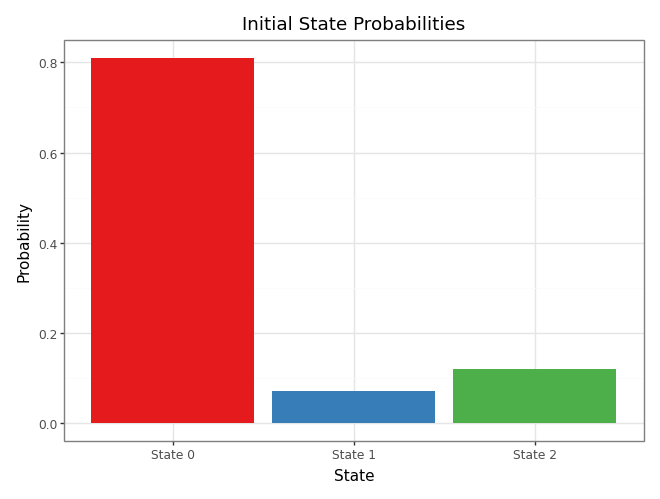

In [89]:
plots["init"]

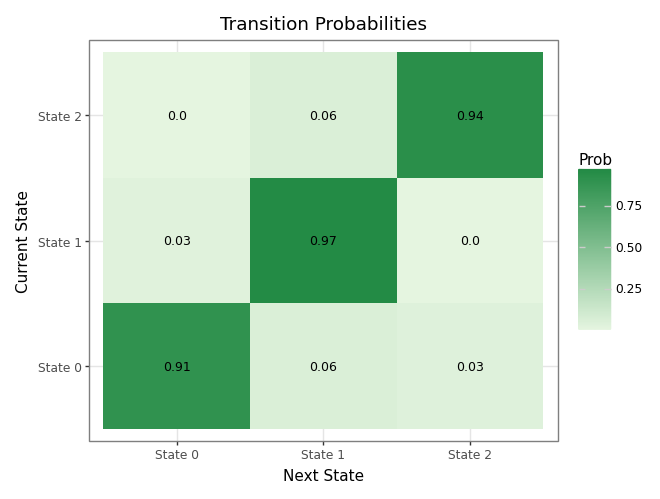

In [90]:
plots["trans"]

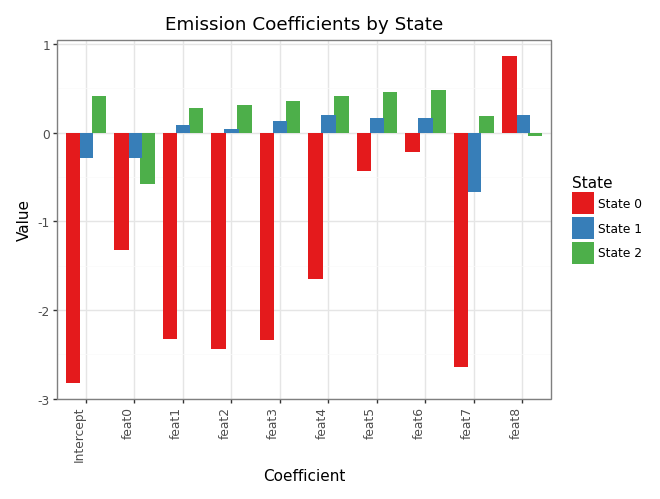

In [91]:
plots["coeffs"]

# Diagnostics

## Viterbi Algorithm

Viterbi decoder\
Goal : for each donor find the MAP latent path $z_{0:T}^\ast$.

Plug-in parameters (posterior means)\
$$\hat\pi_k = \frac{\alpha_{\pi,k}}{\sum_{j}\alpha_{\pi,j}},\qquad
  \hat A_{kj} = \frac{\alpha_{A_{k j}}}{\sum_{j'}\alpha_{A_{k j'}}},\qquad
  \hat\lambda_k = \frac{\alpha_k}{\beta_k}.$$

Dynamic programming\
Initial step\
$$\delta_0(k)=\log\hat\pi_k+\log\text{Poisson}(y_0\mid\hat\lambda_k).$$

Recursion for $t=1,\dots,T$\
$$\delta_t(j)=\max_k\bigl[\delta_{t-1}(k)+\log\hat A_{k j}\bigr]
               +\log\text{Poisson}(y_t\mid\hat\lambda_j),$$\
$$\psi_t(j)=\arg\max_k\bigl[\delta_{t-1}(k)+\log\hat A_{k j}\bigr].$$

Back-tracking\
Start with $z_T^\ast=\arg\max_k\delta_T(k)$, then\
$z_{t-1}^\ast=\psi_t(z_t^\ast)$ for $t=T,\dots,1$.

Cost $O(NTK^2)$ but vectorised in PyTorch, so only a loop on $t$.\
Output tensor paths\[N,T\] of integers 0…K-1, used for diagnostics and plots.


In [93]:
import torch, pyro, torch.nn.functional as F
import pyro.distributions as dist

def log_softmax_logits(logits, dim=-1):
    return logits - logits.logsumexp(dim, keepdim=True)

@torch.no_grad()
def viterbi_paths_cov(obs, x_pi, x_A, x_em=None):
    """
    Viterbi per HMM con:
      - π dipendente da x_pi via W_pi e base pi_base_map
      - A dipendente da x_A via W_A e base A_base_map
      - emissione:
          • GLM Poisson (beta_em) se disponibile e x_em fornito
          • altrimenti Poisson a tasso costante per stato (rates)
    Input:
      obs  : (N,T) long
      x_pi : (N,C_pi)
      x_A  : (N,T,C_A)
      x_em : (N,T,C_em) richiesto se beta_em è nel ParamStore
    Output:
      paths: (N,T) long, percorso MAP per ogni sequenza
    """
    # -------- parametri appresi ----------
    pi_base = pyro.param("pi_base_map")           # (K,)
    A_base  = pyro.param("A_base_map")            # (K,K)
    W_pi    = pyro.param("W_pi")                  # (K,C_pi)
    W_A     = pyro.param("W_A")                   # (K,K,C_A)

    use_glm = "beta_em" in pyro.get_param_store()
    if use_glm:
        beta_em = pyro.param("beta_em")           # (K, 1 + C_em)

    # Device & dtype alignment
    device = W_pi.device
    obs   = obs.to(device)
    x_pi  = x_pi.to(device)
    x_A   = x_A.to(device)
    if use_glm:
        if x_em is None:
            raise ValueError("x_em è richiesto perché beta_em è nel ParamStore.")
        x_em = x_em.to(device)

    N, T = obs.shape
    K    = pi_base.shape[0]

    # -------- emission log-prob ----------
    if use_glm:
        b0 = beta_em[:, 0]              # (K,)
        B  = beta_em[:, 1:]             # (K,C_em)
        # eta = b0_k + x_em @ B_k
        eta = torch.einsum("ntc,kc->ntk", x_em, B) + b0.view(1,1,K)   # (N,T,K)
        emis_log = dist.Poisson(rate=eta.exp()).log_prob(obs.unsqueeze(-1))  # (N,T,K)
    else:
        rates = pyro.param("rates")      # (K,)
        emis_log = torch.stack(
            [dist.Poisson(l).log_prob(obs) for l in rates]            # (K,N,T)
        ).permute(1, 2, 0)                                            # (N,T,K)

    # -------- inizializzazione (t=0) -----
    log_pi_base = (pi_base + 1e-30).log()               # (K,)
    logits0     = log_pi_base + x_pi @ W_pi.T           # (N,K)
    log_pi      = log_softmax_logits(logits0, dim=1)    # (N,K)

    delta = log_pi + emis_log[:, 0]                     # (N,K)
    psi   = torch.zeros(N, T, K, dtype=torch.long, device=device)

    # -------- forward pass --------------
    log_A_base = (A_base + 1e-30).log()                 # (K,K)
    for t in range(1, T):
        x_t   = x_A[:, t, :]                            # (N,C_A)
        # logits[n,k_prev,k_next] = log A_base + <W_A[k_prev,k_next], x_t[n,:]>
        slope  = (W_A.unsqueeze(0) * x_t[:, None, None, :]).sum(-1)   # (N,K,K)
        logits = log_A_base.unsqueeze(0) + slope                       # (N,K,K)
        log_A  = log_softmax_logits(logits, dim=2)                     # row-softmax

        score, idx = (delta.unsqueeze(2) + log_A).max(dim=1)           # max su k_prev
        psi[:, t]  = idx
        delta      = score + emis_log[:, t]

    # -------- back-tracking -------------
    paths        = torch.empty(N, T, dtype=torch.long, device=device)
    last_state   = delta.argmax(dim=1)
    paths[:, -1] = last_state
    for t in range(T-1, 0, -1):
        last_state    = psi[torch.arange(N, device=device), t, last_state]
        paths[:, t-1] = last_state

    return paths.cpu()


In [94]:


paths = viterbi_paths_cov(
    obs_torch,
    cov_init_torch,    # (N,C_pi)
    cov_tran_torch,    # (N,T,C_A)
    cov_emiss_torch    # (N,T,C_em)
)
switch_rate = (paths[:, 1:] != paths[:, :-1]).any(1).float().mean()
print(f"switch rate = {switch_rate:.2%}")



switch rate = 79.35%


## State occupancy over time (population view)

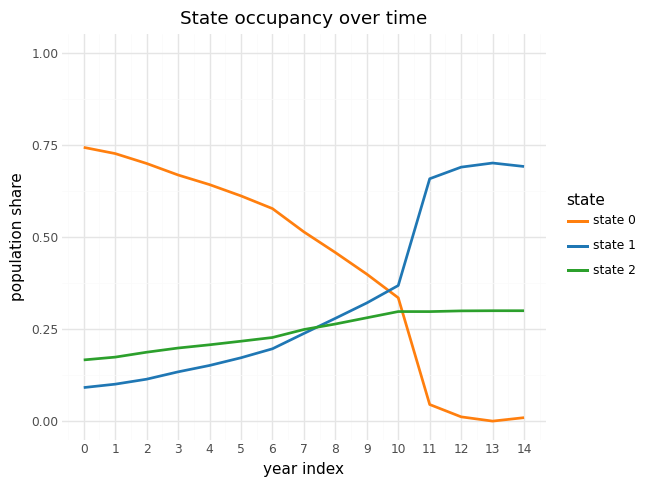

In [101]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_line,
    scale_color_manual, scale_x_continuous, scale_y_continuous,
    labs, theme_minimal, theme, element_text
)

# Accept torch.Tensor or numpy array for `paths` (shape: N,T)
paths_np = paths.detach().cpu().numpy() if hasattr(paths, "detach") else np.asarray(paths)
N, T = paths_np.shape
K = int(paths_np.max()) + 1 if paths_np.size else 1

# Counts per state over time -> (K,T)
counts = np.stack([(paths_np == k).sum(axis=0) for k in range(K)], axis=0)
props = counts / np.maximum(counts.sum(axis=0, keepdims=True), 1)  # avoid div-by-zero

# Build tidy DataFrame
rows = []
for k in range(K):
    for t in range(T):
        rows.append({"t": t, "state": f"state {k}", "share": float(props[k, t])})
df = pd.DataFrame(rows)

# Palette (match original order for K=3)
if K == 3:
    state_cols = ["#ff7f0e", "#1f77b4", "#2ca02c"]  # tab:orange, tab:blue, tab:green
else:
    base = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#ffff33',
            '#a65628','#f781bf','#999999','#66c2a5','#fc8d62','#8da0cb',
            '#e78ac3','#a6d854','#ffd92f']
    state_cols = (base * ((K + len(base) - 1)//len(base)))[:K]

(ggplot(df, aes("t", "share", color="state"))
+ geom_line(size=1.1)
+ scale_color_manual(values=state_cols, name="state")
+ scale_x_continuous(breaks=list(range(T)))
+ scale_y_continuous(limits=(0, 1))
+ labs(x="year index", y="population share", title="State occupancy over time")
+ theme_minimal()
+ theme(axis_text_x=element_text(rotation=0)))

## Individual trajectories

Pick a few donors and overlay observations + decoded state for an easy interpretation of the model.

In [ ]:
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_point, geom_step,
    scale_color_manual, scale_x_continuous, scale_y_continuous,
    labs, theme_minimal, theme, element_text, element_line, element_blank,
    guides, guide_legend
)

# ------------------------------------------------------------
# globals (kept similar to original)
# ------------------------------------------------------------
K_default   = 3
state_cols_default = ['#e41a1c', '#377eb8', '#4daf4a']  # 3 Set1 colors
years_axis  = np.arange(2009, 2024)                    # 2009 .. 2023
yticks_vals = np.arange(0, 5)                          # 0 .. 4

def plot_one_gg(idx, obs_torch, paths, years=years_axis, state_cols=None, y_max=4, title_prefix="Donor"):
    """
    Recreates the original scatter+step plot with plotnine:
      - observed counts (step + points)
      - points colored by discrete latent states with a clean legend
      - x-ticks labeled with years, y-limits clamped to [-0.5, y_max+0.5]
    """
    # -------- extract donor data --------
    x = obs_torch[idx].detach().cpu().numpy() if hasattr(obs_torch, "detach") else np.asarray(obs_torch[idx])
    z = paths[idx].detach().cpu().numpy()     if hasattr(paths, "detach")     else np.asarray(paths[idx], dtype=int)
    years = np.asarray(years, dtype=int)

    T = len(x)
    if len(years) != T:
        raise ValueError("years length must match T for the selected donor.")

    # -------- palette and labels --------
    K = int(np.max(z)) + 1 if z.size > 0 else (state_cols and len(state_cols)) or K_default
    if state_cols is None:
        state_cols = state_cols_default[:K]
    state_labels = [f"State {k}" for k in range(K)]
    z_labs = [state_labels[s] for s in z]

    # -------- build dataframe ----------
    df = pd.DataFrame({
        "t": np.arange(T),
        "year": years,
        "donations": x,
        "state": z_labs
    })

    # -------- assemble plot ------------
    p = (
        ggplot(df, aes("t", "donations"))
        + geom_step(direction="mid", color="black", alpha=0.35)
        + geom_point(aes(color="state"), size=2.6)
        + scale_color_manual(values=state_cols, name="latent state",
                             breaks=state_labels, labels=state_labels)
        + scale_x_continuous(breaks=list(range(T)), labels=[str(y) for y in years])
        + scale_y_continuous(limits=(-0.5, float(y_max) + 0.5), breaks=list(range(0, int(y_max) + 1)))
        + labs(title=f"{title_prefix} {idx}", x="year", y="# donations")
        + theme_minimal()
        + theme(
            axis_text_x=element_text(rotation=45, ha="right"),
            legend_title=element_text(size=10),
            legend_text=element_text(size=9),
            plot_title=element_text(weight="bold"),
            # mimic dotted y-grid only
            panel_grid_major_y=element_line(linetype="dotted", alpha=0.4),
            panel_grid_major_x=element_blank(),
            panel_grid_minor=element_blank()
        )
        + guides(color=guide_legend(title="latent state"))
    )
    return p


# for i in [100, 1002, 3002]:
#     p = plot_one_gg(
#         idx=i,
#         obs_torch=obs_torch,
#         paths=paths,
#         years=years_axis,
#         state_cols=state_cols_default,
#         y_max=4
#     )
#     p
    
    

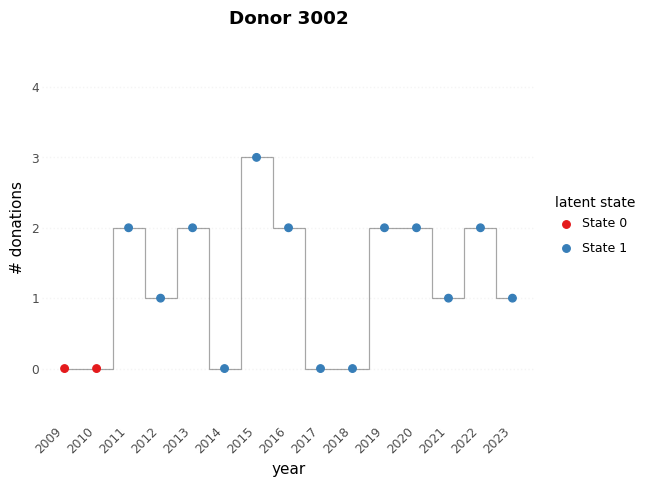

In [107]:
plot_one_gg(
        idx=3002,
        obs_torch=obs_torch,
        paths=paths,
        years=years_axis,
        state_cols=state_cols_default,
        y_max=4
    )

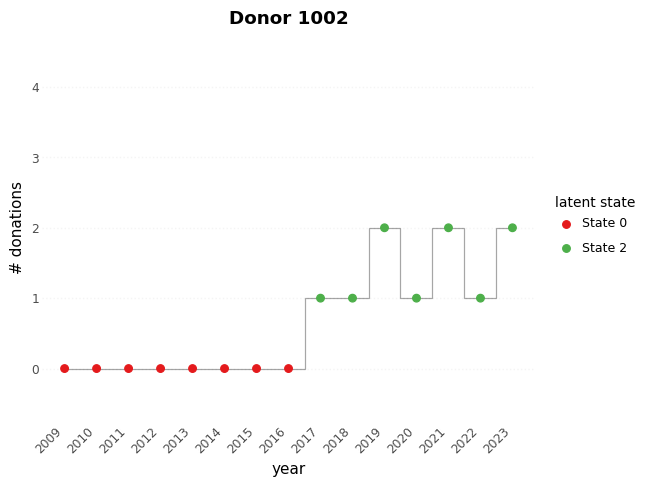

In [106]:
plot_one_gg(
        idx=1002,
        obs_torch=obs_torch,
        paths=paths,
        years=years_axis,
        state_cols=state_cols_default,
        y_max=4
    )

## Covariates

In [11]:
import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.colors import Normalize

# ───────── 1. parametri appresi ────────────────────────────
rates   = pyro.param("rates").detach().cpu().numpy()          # (K,)

pi_base = pyro.param("pi_base_map").detach().cpu().numpy()    # (K,)
W_pi    = pyro.param("W_pi").detach().cpu().numpy()           # (K,2)

A_base  = pyro.param("A_base_map").detach().cpu().numpy()     # (K,K)
W_A     = pyro.param("W_A").detach().cpu().numpy()            # (K,K,2)

K, C_pi = W_pi.shape            # K stati, 2 covariate per π
_, _, C_A = W_A.shape           # 2 covariate per A

# ───────── 2. nomi covariate (adatta se necessario) ─────────
cov_names_pi = ["birth_year_norm", "gender_code"]             # C_pi = 2
cov_names_A  = ["ages_norm",       "covid_years"]             # C_A  = 2

state_cols = ['#e41a1c', '#377eb8', '#4daf4a']                # colori Set1

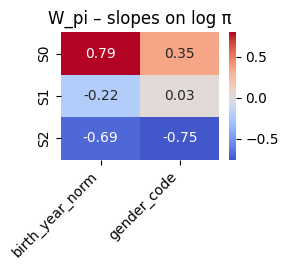

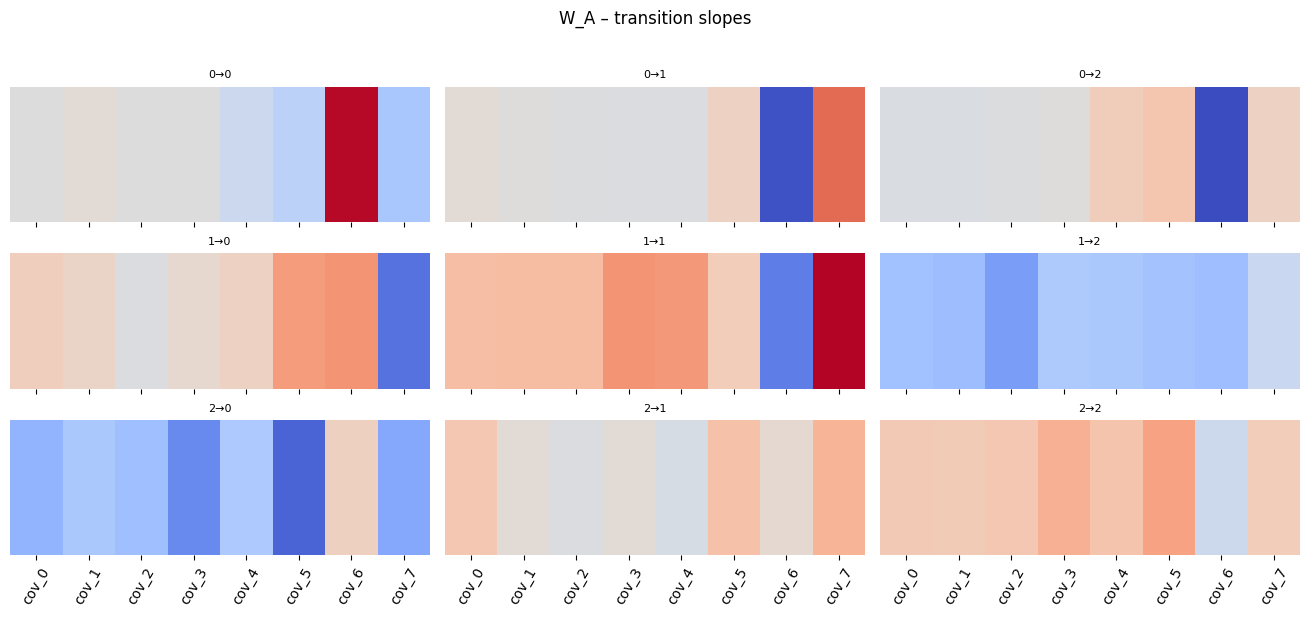

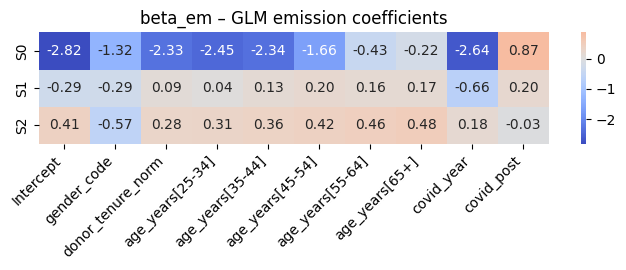

In [112]:
# ============ 1) Utility per nomi covariate con fattori ===================
def expand_factor_names(var_name, levels, ref_level=None, prefix="[", suffix="]"):
    """
    Restituisce i nomi delle colonne dummy per un fattore.
    Se ref_level è dato, lo esclude (schema one-hot con base).
    """
    names = [f"{var_name}{prefix}{lev}{suffix}" for lev in levels]
    if ref_level is not None:
        names = [n for n in names if not n.endswith(f"{ref_level}{suffix}")]
    return names

# ============ 2) Heatmap W_pi (slopes su π) ===============================
def plot_W_pi_heat(W_pi, cov_names_pi=None, title="W_pi – slopes on log π"):
    K, C = W_pi.shape
    if not cov_names_pi or len(cov_names_pi) != C:
        cov_names_pi = [f"cov_{i}" for i in range(C)]

    plt.figure(figsize=(max(3, 0.9*C), max(2.8, 0.5*K + 1)))
    sns.heatmap(
        W_pi,
        annot=True, fmt=".2f",
        xticklabels=cov_names_pi,
        yticklabels=[f"S{k}" for k in range(K)],
        cmap="coolwarm", center=0
    )
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ============ 3) Heatmap W_A (slopes su transizioni) ======================
def plot_W_A_heat(W_A, cov_names_A=None, title="W_A – transition slopes"):
    K, _, C = W_A.shape
    if not cov_names_A or len(cov_names_A) != C:
        cov_names_A = [f"cov_{i}" for i in range(C)]

    fig, axes = plt.subplots(
        K, K,
        figsize=(max(2.0, 0.55*C)*K, max(2.0, 0.8)*K),
        sharex=True, sharey=True
    )
    vmin, vmax = W_A.min(), W_A.max()

    for i in range(K):
        for j in range(K):
            ax = axes[i, j] if K > 1 else axes
            mat = W_A[i, j].reshape(1, -1)  # (1,C)
            sns.heatmap(
                mat, ax=ax, vmin=vmin, vmax=vmax,
                cmap="coolwarm", cbar=False,
                xticklabels=cov_names_A, yticklabels=[]
            )
            ax.set_title(f"{i}→{j}", fontsize=8)
            ax.tick_params(axis="x", labelrotation=60)

    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

# ============ 4) Heatmap beta_em (GLM emissioni per stato) ================
def plot_beta_em_heat(beta_em, cov_names_em=None, title="beta_em – GLM emission coefficients"):
    """
    beta_em: (K, 1 + C_em)  [intercetta, slopes...]
    """
    K, P = beta_em.shape
    C_em = P - 1
    if not cov_names_em or len(cov_names_em) != C_em:
        cov_names_em = [f"em_{i}" for i in range(C_em)]
    colnames = ["Intercept"] + cov_names_em

    plt.figure(figsize=(max(3, 0.7*P), max(2.8, 0.5*K + 1)))
    sns.heatmap(
        beta_em,
        annot=True, fmt=".2f",
        xticklabels=colnames,
        yticklabels=[f"S{k}" for k in range(K)],
        cmap="coolwarm", center=0
    )
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ===================== 5) Esempio di configurazione nomi ==================
# Estrai parametri
W_pi  = pyro.param("W_pi").detach().cpu().numpy()        # (K, C_pi)
W_A   = pyro.param("W_A").detach().cpu().numpy()         # (K, K, C_A)
beta  = pyro.param("beta_em").detach().cpu().numpy()     # (K, 1+C_em)

# Esempio: age_years è un fattore con livelli; è stato codificato a dummies
age_years_levels = ["<25","25-34","35-44","45-54","55-64","65+"]
ref_age_level = "<25"   # se hai usato one-hot con base, metti il livello di riferimento

# Covariate per π (adatta alla tua pipeline)
cov_names_pi = [
    "birth_year_norm",
    "gender_code"
]

# Covariate per A: espansione fattoriale + altre
age_fac_cols = expand_factor_names("age_years", age_years_levels, ref_level=ref_age_level)
# Aggiungi altre covariate di transizione (es. covid_years, trend, ecc.)
cov_names_A = age_fac_cols + ["covid_years"]

# Covariate per emissioni (GLM): possono includere fattori e continui
# Esempio: stato civile fattoriale + age_years fattoriale + indicatori covid
marital_levels = ["S","M","D","W"]
ref_marital = "S"
marital_cols = expand_factor_names("marital", marital_levels, ref_level=ref_marital)

em_age_fac_cols = expand_factor_names("age_years", age_years_levels, ref_level=ref_age_level)
cov_names_em = ["gender_code", "donor_tenure_norm"] + em_age_fac_cols + ["covid_year", "covid_post"]

# Nota importante:
# - L’ordine e il numero dei nomi devono combaciare con le colonne effettive
#   usate in training per W_A e beta_em. Se non coincidono, riadatta le liste sopra.

# ===================== 6) Chiamate ai plot ================================
plot_W_pi_heat(W_pi, cov_names_pi)
plot_W_A_heat(W_A, cov_names_A)
plot_beta_em_heat(beta, cov_names_em)

In [113]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================
# 1) Statistiche per z-scoring SOLO per variabili continue
# ==============================================================

# birth-year
birth_year_orig = df["birth_year"].to_numpy()
birth_year_mean = birth_year_orig.mean()
birth_year_std  = birth_year_orig.std()

# ages (N×T) costruite da birth_year e anni di calendario
years_num = np.array([int(c[2:]) for c in sorted([c for c in df.columns if c.startswith("y_")])])
ages      = years_num[None, :] - df["birth_year"].to_numpy()[:, None]
ages_mean = ages.mean()
ages_std  = ages.std()

# mean / std usate per z-scoring delle sole continue
stats = {
    "birth_year_norm": (birth_year_mean, birth_year_std),
    "ages_norm":       (ages_mean,        ages_std),
    # aggiungi qui altre variabili continue normalizzate se presenti
}

def to_norm(var_name: str, x_orig: np.ndarray) -> np.ndarray:
    """
    Convert ORIGINAL values -> z-scored scale (per continue).
    I fattori restano invariati (gestiti via dummies).
    """
    if var_name in stats:
        mu, sd = stats[var_name]
        return (x_orig - mu) / sd
    return x_orig  # binarie o fattoriali gestite a parte

# ==============================================================
# 2) Gestione fattori (one-hot con riferimento)
# ==============================================================

def build_factor_cols(cov_names, factor_name, levels, ref_level):
    """
    Ricostruisce l'indice delle colonne dummificate per un fattore:
    cerca pattern 'factor_name[LEVEL]' in cov_names.
    Ritorna: dict {level -> col_index or None se livello è la base (reference)}.
    """
    name_to_idx = {n: i for i, n in enumerate(cov_names)}
    mapping = {}
    for lev in levels:
        col_name = f"{factor_name}[{lev}]"
        if lev == ref_level:
            mapping[lev] = None  # livello di riferimento → tutte dummies a 0
        else:
            if col_name not in name_to_idx:
                raise ValueError(f"Manca la colonna dummy {col_name} in cov_names.")
            mapping[lev] = name_to_idx[col_name]
    return mapping

def set_factor_level_in_vector(x_vec, factor_map, all_dummy_indices, level):
    """
    Imposta in-place il livello del fattore in un vettore design.
    - azzera tutte le dummies del fattore
    - se level ha una colonna dedicata, la pone a 1 (altrimenti resta tutto 0 → riferimento)
    """
    x_vec[all_dummy_indices] = 0.0
    idx = factor_map[level]
    if idx is not None:
        x_vec[idx] = 1.0

# ==============================================================
# 3) ORIGINAL values per covariate (continui, binari, fattori)
# ==============================================================

def original_values(var_name: str,
                    factor_levels: dict | None = None,
                    df=df,
                    ages_matrix=ages) -> np.ndarray:
    """
    Restituisce valori ORIGINALI per la covariata richiesta.
    - Se fattore: ritorna l’elenco livelli (array di stringhe).
    - Se continuo: ritorna i valori originali.
    - Se binario: ritorna [0., 1.].
    factor_levels: opzionale, es. {"age_years": ["<25","25-34",...]}
    """
    # continue note
    if var_name == "birth_year_norm":
        return df["birth_year"].to_numpy()
    if var_name == "ages_norm":
        return ages_matrix.reshape(-1)

    # binarie note
    if var_name == "gender_code":
        return np.array([0.0, 1.0])
    if var_name == "covid_years":
        return np.array([0.0, 1.0])

    # fattori: prendi i livelli dichiarati
    if factor_levels and var_name in factor_levels:
        return np.array(factor_levels[var_name], dtype=object)

    # fallback: se esiste come colonna fattoriale in df
    if var_name in df.columns and (df[var_name].dtype == "category" or df[var_name].dtype == object):
        return np.array(sorted(pd.unique(df[var_name].astype(str))), dtype=object)

    raise ValueError(f"Unknown covariate {var_name}")

# ==============================================================
# 4) Softmax helper
# ==============================================================

def softmax(v):
    v = v - v.max()
    e = np.exp(v)
    return e / e.sum()

# ==============================================================
# 5) π_k(x) vs covariata (original scale), con fattori e continui
# ==============================================================

def plot_pi_vs_cov_orig(
    var,
    cov_names_pi,
    W_pi,
    log_pi0,
    x_pi_data=None,               # (N, C_pi) già normalizzata
    x_pi_ref=None,                # (C_pi,) opzionale, se vuoi un reference fisso
    factor_specs_pi=None,         # dict: { "age_years": {"levels":[...], "ref":"<25"} , ... }
    grid_orig=None,
    state_cols=None,
    title_prefix="Initial-state probability vs "
):
    """
    Disegna π_k(x) al variare di una covariata (continua o fattore).
    - Per continue: curva.
    - Per fattori: punti/bars per livello.
    """
    K = W_pi.shape[0]
    if state_cols is None:
        state_cols = ['#e41a1c', '#377eb8', '#4daf4a'][:K]

    # Base/reference vector sullo spazio normalizzato
    if x_pi_ref is None:
        if x_pi_data is None:
            # prova a recuperare da torch → numpy se disponibile
            if "cov_init_torch" in globals():
                x_pi_data = cov_init_torch.cpu().numpy()
            elif "x_pi_data" in globals():
                x_pi_data = globals()["x_pi_data"]
            else:
                raise ValueError("Serve x_pi_data (o x_pi_ref) per definire il vettore di riferimento.")
        x_ref_norm = x_pi_data.mean(0)   # (C_pi,)
    else:
        x_ref_norm = x_pi_ref.copy()

    # Rileva se var è fattore
    is_factor = factor_specs_pi is not None and var in factor_specs_pi

    if is_factor:
        # specifiche fattore
        levels = factor_specs_pi[var]["levels"]
        ref    = factor_specs_pi[var]["ref"]
        # mappa livello -> indice colonna (None per ref)
        factor_map = build_factor_cols(cov_names_pi, var, levels, ref)
        # indici delle colonne dummificate di questo fattore (tutte le non-ref)
        dummy_indices = [idx for idx in factor_map.values() if idx is not None]
        grid_levels = levels if grid_orig is None else grid_orig  # lista livelli

        # calcolo π per ogni livello
        curves = []
        for lev in grid_levels:
            x_norm = x_ref_norm.copy()
            set_factor_level_in_vector(x_norm, factor_map, dummy_indices, lev)
            logits = log_pi0 + W_pi @ x_norm
            curves.append(softmax(logits))
        curves = np.vstack(curves)  # (G, K)

        # plot (bar/points per livello)
        fig, ax = plt.subplots(figsize=(7, 3.2))
        x_pos = np.arange(len(grid_levels))
        width = 0.8 / K
        for k, c in enumerate(state_cols):
            ax.bar(x_pos + k*width - 0.4 + width*K/2, curves[:, k], width=width, color=c, label=f"state {k}")
        ax.set_xticks(x_pos); ax.set_xticklabels(grid_levels, rotation=45, ha="right")
        ax.set_ylabel("π_k(x)")
        ax.set_title(f"{title_prefix}{var}")
        ax.grid(axis="y", ls=":", alpha=0.4)
        ax.legend()
        plt.tight_layout(); plt.show()

    else:
        # continua/binaria singola colonna già in cov_names_pi
        if var not in cov_names_pi:
            raise ValueError(f"{var} non è nei cov_names_pi e non risulta specificato come fattore.")
        idx = cov_names_pi.index(var)
        col_orig = original_values(var)
        # griglia ORIGINAL
        if grid_orig is None:
            uniq = np.unique(col_orig)
            grid_orig = uniq if len(uniq) <= 6 else np.linspace(col_orig.min(), col_orig.max(), 41)

        curves = []
        for v_orig in grid_orig:
            x_norm      = x_ref_norm.copy()
            x_norm[idx] = to_norm(var, v_orig)
            logits      = log_pi0 + W_pi @ x_norm
            curves.append(softmax(logits))
        curves = np.vstack(curves)  # (G, K)

        # plot (curva/linea)
        for k, c in enumerate(state_cols):
            plt.plot(grid_orig, curves[:, k], color=c, label=f"state {k}")
        plt.xlabel(var.replace("_norm", ""));  plt.ylabel("π_k(x)")
        plt.title(f"{title_prefix}{var.replace('_norm', '')}")
        plt.grid(ls=":", alpha=0.5);  plt.legend();  plt.tight_layout();  plt.show()

# ==============================================================
# 6) λ_k(x_em) del GLM emissioni vs covariata (fattori/continui)
# ==============================================================

def plot_lambda_em_vs_cov(
    var_em,
    beta_em,                # (K, 1 + C_em)
    cov_names_em,           # lunghezza = C_em
    x_em_data=None,         # (N, T, C_em) o (N, C_em) per media di riferimento
    x_em_ref=None,          # (C_em,) opzionale
    factor_specs_em=None,   # dict: { "age_years": {"levels":[...], "ref":"<25"} , ... }
    grid_orig=None,
    state_cols=None,
    title_prefix="Emission GLM λ_k vs "
):
    """
    Plotta la λ_k = exp(b0_k + x_em · B_k) variando una sola covariata di emissione.
    Gestisce sia continui che fattori (dummies con riferimento).
    """
    K, P = beta_em.shape
    C_em = P - 1
    if state_cols is None:
        state_cols = ['#e41a1c', '#377eb8', '#4daf4a'][:K]

    # reference su x_em
    if x_em_ref is None:
        if x_em_data is None:
            if "cov_emiss_torch" in globals():
                X = cov_emiss_torch.cpu().numpy()
                x_em_ref = X.mean(axis=(0, 1))  # media su N,T
            else:
                raise ValueError("Serve x_em_data o x_em_ref per definire il vettore di riferimento.")
        else:
            X = x_em_data
            if X.ndim == 3:
                x_em_ref = X.mean(axis=(0, 1))
            elif X.ndim == 2:
                x_em_ref = X.mean(axis=0)
            else:
                raise ValueError("x_em_data deve essere (N,T,C_em) o (N,C_em).")

    b0 = beta_em[:, 0]      # (K,)
    B  = beta_em[:, 1:]     # (K, C_em)

    # fattore?
    is_factor = factor_specs_em is not None and var_em in factor_specs_em

    if is_factor:
        levels = factor_specs_em[var_em]["levels"]
        ref    = factor_specs_em[var_em]["ref"]
        # ricostruisci mappa livello->indice colonna
        fac_map = build_factor_cols(cov_names_em, var_em, levels, ref)
        dummy_idx = [i for i in fac_map.values() if i is not None]
        grid_levels = levels if grid_orig is None else grid_orig

        lam = np.zeros((len(grid_levels), K))
        for g, lev in enumerate(grid_levels):
            x_ref = x_em_ref.copy()
            # azzera dummies e setta il livello
            if dummy_idx:
                x_ref[dummy_idx] = 0.0
            idx = fac_map[lev]
            if idx is not None:
                x_ref[idx] = 1.0
            eta = b0 + B @ x_ref
            lam[g] = np.exp(eta)

        # plot bar per stato
        x_pos = np.arange(len(grid_levels))
        width = 0.8 / K
        fig, ax = plt.subplots(figsize=(7, 3.2))
        for k, c in enumerate(state_cols):
            ax.bar(x_pos + k*width - 0.4 + width*K/2, lam[:, k], width=width, color=c, label=f"state {k}")
        ax.set_xticks(x_pos); ax.set_xticklabels(grid_levels, rotation=45, ha="right")
        ax.set_ylabel("λ_k")
        ax.set_title(f"{title_prefix}{var_em}")
        ax.grid(axis="y", ls=":", alpha=0.4)
        ax.legend()
        plt.tight_layout(); plt.show()

    else:
        # continuo / binario singolo
        if var_em not in cov_names_em:
            raise ValueError(f"{var_em} non è in cov_names_em e non risulta specificato come fattore.")
        j = cov_names_em.index(var_em)
        # griglia ORIGINAL (niente z-score: emissioni GLM usano la scala del design)
        if grid_orig is None:
            # prova a inferire dal campione se disponibile
            if x_em_data is not None:
                X = x_em_data
                vals = X.reshape(-1, X.shape[-1])[:, j]
                uniq = np.unique(vals)
                grid_orig = uniq if len(uniq) <= 6 else np.linspace(vals.min(), vals.max(), 41)
            else:
                # fallback generico
                grid_orig = np.linspace(-2, 2, 41)

        lam = np.zeros((len(grid_orig), K))
        for g, v in enumerate(grid_orig):
            x_ref = x_em_ref.copy()
            x_ref[j] = v
            eta = b0 + B @ x_ref
            lam[g] = np.exp(eta)

        for k, c in enumerate(state_cols):
            plt.plot(grid_orig, lam[:, k], color=c, label=f"state {k}")
        plt.xlabel(var_em); plt.ylabel("λ_k")
        plt.title(f"{title_prefix}{var_em}")
        plt.grid(ls=":", alpha=0.5); plt.legend(); plt.tight_layout(); plt.show()



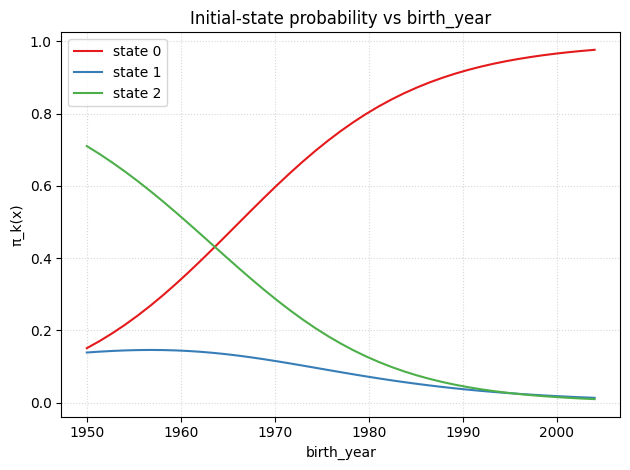

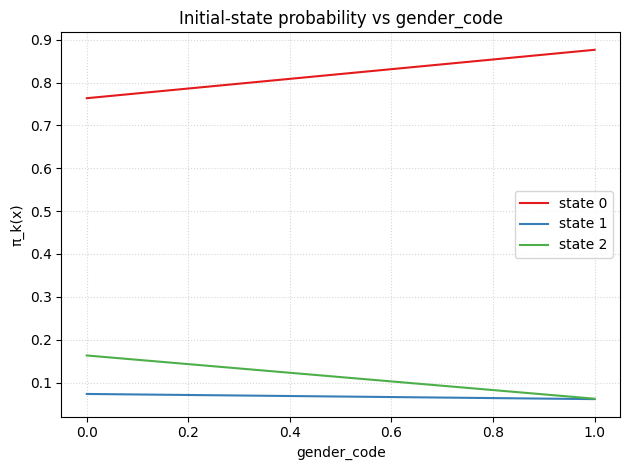

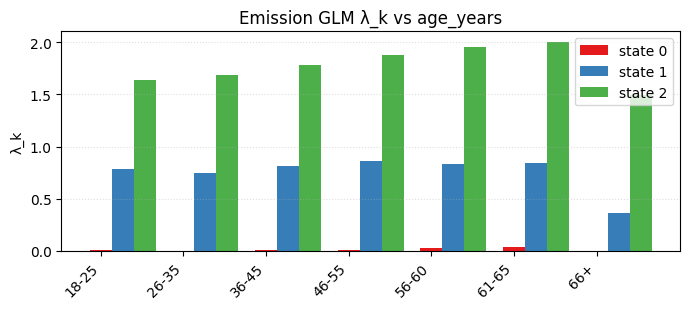

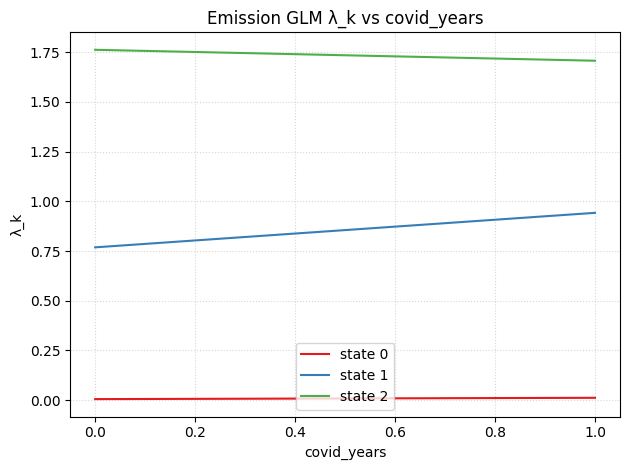

In [114]:
import numpy as np

# 1) Costruisci i label delle classi d’età dai break che hai usato
#    (devono essere gli stessi usati per ages_onehot / cov_tran / cov_emission)
age_bins = np.array([18, 26, 36, 46, 56, 61, 66, 200])  # 18–25, 26–35, 36–45, 46–55, 56–60, 61–65, 66+
def age_labels_from_bins(edges):
    labs = []
    for a, b in zip(edges[:-2], edges[1:-1]):
        labs.append(f"{a}-{b-1}")  # intervalli [a,b)
    labs.append(f"{edges[-2]}+")   # ultimo aperto in alto
    return labs

age_levels = age_labels_from_bins(age_bins)  # ['18-25','26-35','36-45','46-55','56-60','61-65','66+']

# 2) Specifiche fattori
#    - π: non hai fattori (solo birth_year_norm, gender_code), quindi vuoto.
#    - Emissioni: age_years è fattore con tutte le dummies incluse → ref=None.
factor_specs_pi = {}  # nessun fattore in x_pi

factor_specs_em = {
    "age_years": {
        "levels": age_levels,
        "ref": None  # IMPORTANT: hai tutte le dummies, non ometti il riferimento
    }
    # se in futuro aggiungi altri fattori (es. marital), aggiungili qui
}

# 3) Nomi colonne design, allineati all’ordine con cui hai costruito i tensori
#    π: [birth_year_norm, gender_code]
cov_names_pi = ["birth_year_norm", "gender_code"]

#    A: [age_years[...]*7, covid_years] → 8 feature
cov_names_A = [f"age_years[{lab}]" for lab in age_levels] + ["covid_years"]

#    Emissioni: [gender(1), age_years(7), covid(1)] → 9 feature
cov_names_em = ["gender_code"] + [f"age_years[{lab}]" for lab in age_levels] + ["covid_years"]

# 4) Recupero parametri e reference dai tensori che hai già
import pyro
W_pi   = pyro.param("W_pi").detach().cpu().numpy()                 # (K, C_pi=2)
pi_base = pyro.param("pi_base_map").detach().cpu().numpy()         # (K,)
log_pi0 = np.log(np.clip(pi_base, 1e-30, None))                    # stabilizza

# Emissioni GLM (se presenti)
has_beta = "beta_em" in pyro.get_param_store()
if has_beta:
    beta_em = pyro.param("beta_em").detach().cpu().numpy()         # (K, 1 + C_em=9)

# Reference: medie campionarie (o passane una personalizzata)
x_pi_data = cov_init_torch.detach().cpu().numpy()                  # (N, 2)
x_em_data = cov_emiss_torch.detach().cpu().numpy()                 # (N, T, 9)

# 5) Esempi di chiamata ai plot (usando le funzioni che ti ho dato prima)

# π_k(x) vs birth_year_norm (continuo)
plot_pi_vs_cov_orig(
    var="birth_year_norm",
    cov_names_pi=cov_names_pi,
    W_pi=W_pi,
    log_pi0=log_pi0,
    x_pi_data=x_pi_data,
    factor_specs_pi=factor_specs_pi  # vuoto
)

# π_k(x) vs gender_code (binaria)
plot_pi_vs_cov_orig(
    var="gender_code",
    cov_names_pi=cov_names_pi,
    W_pi=W_pi,
    log_pi0=log_pi0,
    x_pi_data=x_pi_data,
    factor_specs_pi=factor_specs_pi
)

# λ_k(emissione) vs age_years (fattore con 7 livelli)
if has_beta:
    plot_lambda_em_vs_cov(
        var_em="age_years",
        beta_em=beta_em,
        cov_names_em=cov_names_em,
        x_em_data=x_em_data,              # media su N,T come reference
        factor_specs_em=factor_specs_em    # levels=age_levels, ref=None
    )

# λ_k(emissione) vs covid_years (binaria 0/1)
if has_beta:
    plot_lambda_em_vs_cov(
        var_em="covid_years",
        beta_em=beta_em,
        cov_names_em=cov_names_em,
        x_em_data=x_em_data
    )

In [119]:
import numpy as np
import matplotlib.pyplot as plt
import pyro

# ---------- helpers ---------------------------------------------------------
def softmax(v):
    v = v - v.max()
    e = np.exp(v)
    return e / e.sum()

def build_factor_cols(cov_names, factor_name, levels, ref=None):
    """
    Ritorna: dict {level -> indice colonna (o None se ref)}, e la lista di tutti
    gli indici dummy del fattore (utile per azzerarle prima di impostare un livello).
    Nota: se ref=None significa che nel design sono presenti tutte le dummies.
    """
    name_to_idx = {n: i for i, n in enumerate(cov_names)}
    mapping = {}
    all_dummy_idx = []
    for lev in levels:
        col = f"{factor_name}[{lev}]"
        if (ref is not None) and (lev == ref):
            mapping[lev] = None
        else:
            if col not in name_to_idx:
                raise ValueError(f"Colonna dummy mancante: {col}")
            idx = name_to_idx[col]
            mapping[lev] = idx
            all_dummy_idx.append(idx)
    return mapping, all_dummy_idx

def set_factor_level_in_vector(x_vec, factor_map, all_dummy_idx, level):
    x_vec[all_dummy_idx] = 0.0
    idx = factor_map[level]
    if idx is not None:
        x_vec[idx] = 1.0

# Se hai già original_values, to_norm, cov_names_pi/A/em, x_pi_data, ecc. usali.
# Altrimenti questi fallback recuperano dal ParamStore/tensori globali.

def get_W_A_and_logA():
    W_A = pyro.param("W_A").detach().cpu().numpy()          # (K,K,C_A)
    A0  = pyro.param("A_base_map").detach().cpu().numpy()   # (K,K)
    log_A0 = np.log(np.clip(A0, 1e-30, None))
    return W_A, log_A0

def get_pi_params():
    W_pi   = pyro.param("W_pi").detach().cpu().numpy()                # (K,C_pi)
    pi_base = pyro.param("pi_base_map").detach().cpu().numpy()        # (K,)
    log_pi0 = np.log(np.clip(pi_base, 1e-30, None))
    return W_pi, log_pi0

def get_emission_params_and_ref(cov_emiss_torch):
    has_beta = "beta_em" in pyro.get_param_store()
    if not has_beta:
        return None, None, None
    beta_em = pyro.param("beta_em").detach().cpu().numpy()            # (K,1+C_em)
    X = cov_emiss_torch.detach().cpu().numpy()                        # (N,T,C_em)
    x_em_ref = X.mean(axis=(0,1))                                     # (C_em,)
    return beta_em, x_em_ref, X.shape[-1]

# Palette default
def default_state_cols(K):
    base = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33',
            '#a65628', '#f781bf', '#999999']
    return (base * ((K + len(base) - 1)//len(base)))[:K]

# =====================================================================
# Transition probabilities vs covariata (ORIGINAL scale, fattori ok)
# =====================================================================
def plot_trans_vs_cov_orig(
    var,
    prev_state=0,
    grid_orig=None,
    cov_names_A=None,
    x_A_data=None,        # (N,T,C_A) per vettore di riferimento (media)
    W_A=None, log_A0=None,
    factor_specs_A=None,  # es.: {"age_years": {"levels": [...], "ref": None}}
    state_cols=None
):
    # Recuperi di default se non passati
    if cov_names_A is None:
        raise ValueError("Serve cov_names_A (lista nomi colonne di A).")
    if (W_A is None) or (log_A0 is None):
        W_A, log_A0 = get_W_A_and_logA()
    if x_A_data is None:
        # prova da tensore globale
        if "cov_tran_torch" in globals():
            x_A_data = cov_tran_torch.detach().cpu().numpy()
        else:
            raise ValueError("Serve x_A_data (N,T,C_A) o cov_tran_torch globale.")
    K = W_A.shape[0]
    if state_cols is None:
        state_cols = default_state_cols(K)
    if prev_state >= K:
        raise ValueError("prev_state out of range")

    # vettore di riferimento (media su N,T)
    x_ref = x_A_data.mean(axis=(0,1)).copy()   # (C_A,)

    # Caso FATTORIALE (var è un fattore, es. "age_years")
    is_factor = (factor_specs_A is not None) and (var in factor_specs_A)
    if is_factor:
        levels = factor_specs_A[var]["levels"]
        ref    = factor_specs_A[var].get("ref", None)
        factor_map, all_dummy_idx = build_factor_cols(cov_names_A, var, levels, ref)

        mats = np.zeros((len(levels), K))
        for g, lev in enumerate(levels):
            x_vec = x_ref.copy()
            set_factor_level_in_vector(x_vec, factor_map, all_dummy_idx, lev)
            logits = log_A0[prev_state] + (W_A[prev_state] @ x_vec)   # (K,)
            mats[g] = softmax(logits)

        # barplot raggruppato per j
        fig, ax = plt.subplots(figsize=(8, 3.2))
        x_pos = np.arange(len(levels))
        width = 0.8 / K
        for j, c in enumerate(state_cols):
            ax.bar(x_pos + j*width - 0.4 + width*K/2, mats[:, j], width=width, color=c, label=f"{prev_state}→{j}")
        ax.set_xticks(x_pos); ax.set_xticklabels(levels, rotation=45, ha="right")
        ax.set_ylabel("transition prob."); ax.set_xlabel(var)
        ax.set_title(f"Transition from state {prev_state} vs {var}")
        ax.grid(axis="y", ls=":", alpha=0.4); ax.legend(); plt.tight_layout(); plt.show()
        return

    # Caso CONTINUO/BINARIO (var è una singola colonna di A)
    if var not in cov_names_A:
        raise ValueError(f"{var} non trovato in cov_names_A e non specificato come fattore.")
    idx = cov_names_A.index(var)

    # grid (ORIGINALE): se binaria → {0,1}
    if grid_orig is None:
        # prova a inferire dai dati
        vals = x_A_data[..., idx].reshape(-1)
        uniq = np.unique(vals)
        grid_orig = uniq if len(uniq) <= 6 else np.linspace(vals.min(), vals.max(), 41)

    mats = np.zeros((len(grid_orig), K))
    for g, v in enumerate(grid_orig):
        x_vec = x_ref.copy()
        x_vec[idx] = v
        logits = log_A0[prev_state] + (W_A[prev_state] @ x_vec)
        mats[g] = softmax(logits)

    # line plot
    for j, c in enumerate(state_cols):
        plt.plot(grid_orig, mats[:, j], color=c, label=f"{prev_state}→{j}")
    plt.xlabel(var); plt.ylabel("transition prob.")
    plt.title(f"Transition from state {prev_state} vs {var}")
    plt.grid(ls=":"); plt.legend(); plt.tight_layout(); plt.show()

# =====================================================================
# Expected E[y0 | x] vs π-covariata (ORIG scale) con emissioni GLM
# =====================================================================
def expected_y_orig(
    var,
    grid_orig=None,
    cov_names_pi=None,
    x_pi_data=None,    # (N, C_pi) normalizzate (come in training)
    W_pi=None, log_pi0=None,
    rates=None,                 # fallback se non c’è beta_em
    cov_names_em=None,
    cov_emiss_torch=None        # per x_em_ref medio
):
    # parametri π
    if cov_names_pi is None:
        raise ValueError("Serve cov_names_pi (lista nomi colonne di π).")
    if (W_pi is None) or (log_pi0 is None):
        W_pi, log_pi0 = get_pi_params()
    if x_pi_data is None:
        if "cov_init_torch" in globals():
            x_pi_data = cov_init_torch.detach().cpu().numpy()
        else:
            raise ValueError("Serve x_pi_data o cov_init_torch globale.")
    K = W_pi.shape[0]

    # emissioni: GLM se disponibile, altrimenti rates
    beta_em, x_em_ref, C_em = (None, None, None)
    if "beta_em" in pyro.get_param_store():
        if (cov_names_em is None) or (cov_emiss_torch is None):
            raise ValueError("Per emissioni GLM servono cov_names_em e cov_emiss_torch.")
        beta_em, x_em_ref, C_em = get_emission_params_and_ref(cov_emiss_torch)
        b0 = beta_em[:, 0]
        B  = beta_em[:, 1:]
        lam = np.exp(b0 + B @ x_em_ref)   # (K,)
    else:
        if rates is None:
            rates = pyro.param("rates").detach().cpu().numpy()
        lam = rates.copy()  # (K,)

    # griglia per var
    if var not in cov_names_pi:
        raise ValueError(f"{var} non è una covariata di π.")
    idx = cov_names_pi.index(var)
    # inferisci originale dalla colonna x_pi_data (già normalizzata) non è possibile;
    # quindi se hai original_values(var) usala, altrimenti fai una griglia ragionevole:
    if grid_orig is None:
        if "original_values" in globals():
            col_orig = original_values(var)
            uniq = np.unique(col_orig)
            grid_orig = uniq if len(uniq) <= 6 else np.linspace(col_orig.min(), col_orig.max(), 41)
        else:
            # fallback: se binaria o continuo standard
            col_norm = x_pi_data[:, idx]
            lo, hi = np.percentile(col_norm, [1, 99])
            # prova a invertire z-score? Se hai to_norm inverse non disponibile, usa campione
            grid_orig = np.linspace(lo, hi, 41)

    # riferimento su π: media campionaria
    x_ref = x_pi_data.mean(axis=0).copy()  # (C_pi,)
    exp_vals = []
    for v_orig in grid_orig:
        # se esiste to_norm(), converte originale → z-score, altrimenti assume già pronta
        if "to_norm" in globals():
            v_norm = to_norm(var, v_orig)
        else:
            v_norm = v_orig
        x_vec = x_ref.copy()
        x_vec[idx] = v_norm
        pi_x = softmax(log_pi0 + W_pi @ x_vec)     # (K,)
        exp_vals.append(float(np.dot(pi_x, lam)))

    plt.plot(grid_orig, exp_vals, "-o")
    plt.xlabel(var.replace("_norm", "")); plt.ylabel("E[y₀ | x]")
    plt.title(f"Expected count at t=0 vs {var.replace('_norm','')}")
    plt.grid(ls=":"); plt.tight_layout(); plt.show()


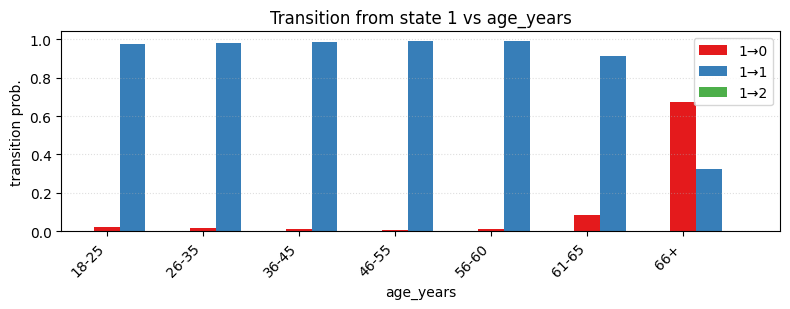

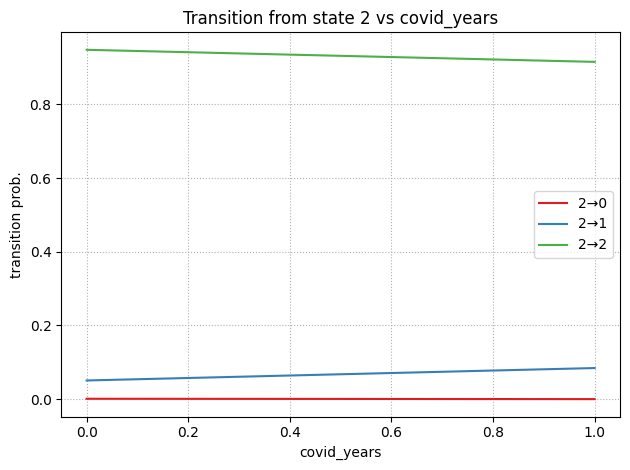

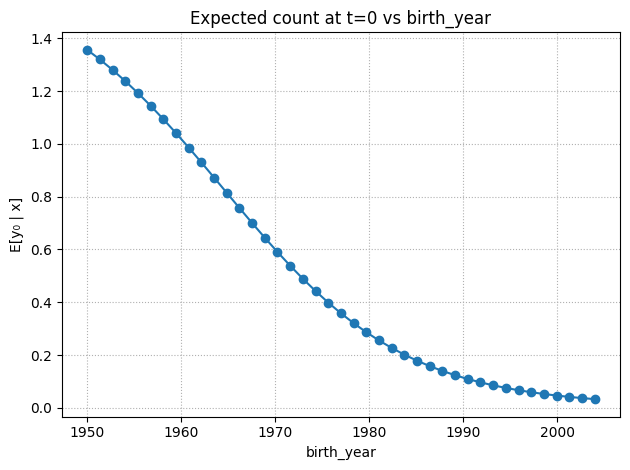

In [121]:
# 1) Specifiche fattore per A: age_years con tutte le dummies (ref=None)
age_bins = np.array([18, 26, 36, 46, 56, 61, 66, 200])
def age_labels_from_bins(edges):
    labs = []
    for a, b in zip(edges[:-2], edges[1:-1]):
        labs.append(f"{a}-{b-1}")
    labs.append(f"{edges[-2]}+")
    return labs
age_levels = age_labels_from_bins(age_bins)

factor_specs_A = {
    "age_years": {"levels": age_levels, "ref": None}
}

# 2) Nomi colonne (allineati al design che hai costruito)
#    A: [age_years[...]*7, covid_years]
cov_names_A = [f"age_years[{lab}]" for lab in age_levels] + ["covid_years"]

#    π: ["birth_year_norm", "gender_code"]
cov_names_pi = ["birth_year_norm", "gender_code"]

#    emissioni: ["gender_code"] + age dummies + ["covid_years"]
cov_names_em = ["gender_code"] + [f"age_years[{lab}]" for lab in age_levels] + ["covid_years"]

# 3) Chiamate
# Transitions vs age_years (fattore)
plot_trans_vs_cov_orig(
    var="age_years",
    prev_state=1,
    cov_names_A=cov_names_A,
    x_A_data=cov_tran_torch.detach().cpu().numpy(),
    factor_specs_A=factor_specs_A
)

# Transitions vs covid_years (binaria)
plot_trans_vs_cov_orig(
    var="covid_years",
    prev_state=2,
    cov_names_A=cov_names_A,
    x_A_data=cov_tran_torch.detach().cpu().numpy()
)

# Expected y vs π covariata (usa emissioni GLM se presenti, altrimenti rates)
W_pi, log_pi0 = get_pi_params()
expected_y_orig(
    var="birth_year_norm",
    cov_names_pi=cov_names_pi,
    x_pi_data=cov_init_torch.detach().cpu().numpy(),
    W_pi=W_pi, log_pi0=log_pi0,
    cov_names_em=cov_names_em,
    cov_emiss_torch=cov_emiss_torch  # richiesto se hai beta_em
)


In [123]:

import numpy as np
import matplotlib.pyplot as plt
import pyro

def softmax(v):
    v = v - v.max()
    e = np.exp(v)
    return e / e.sum()

def default_state_cols(K):
    base = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33',
            '#a65628', '#f781bf', '#999999']
    return (base * ((K + len(base) - 1)//len(base)))[:K]

# Nuovo helper senza collisioni
def factor_mapping_from_names(cov_names, factor_name, levels, ref=None):
    """
    Ritorna (mapping, all_dummy_idx):
      - mapping: {level -> indice colonna o None se ref}
      - all_dummy_idx: lista di tutti gli indici dummy di questo fattore
    """
    name_to_idx = {n: i for i, n in enumerate(cov_names)}
    mapping = {}
    all_dummy_idx = []
    for lev in levels:
        col = f"{factor_name}[{lev}]"
        if (ref is not None) and (lev == ref):
            mapping[lev] = None
        else:
            if col not in name_to_idx:
                raise ValueError(f"Manca la colonna dummy: {col}")
            idx = name_to_idx[col]
            mapping[lev] = idx
            all_dummy_idx.append(idx)
    return mapping, all_dummy_idx

def set_factor_level_in_vector(x_vec, factor_map, all_dummy_idx, level):
    x_vec[all_dummy_idx] = 0.0
    idx = factor_map[level]
    if idx is not None:
        x_vec[idx] = 1.0

def get_W_A_and_logA():
    W_A = pyro.param("W_A").detach().cpu().numpy()          # (K,K,C_A)
    A0  = pyro.param("A_base_map").detach().cpu().numpy()   # (K,K)
    log_A0 = np.log(np.clip(A0, 1e-30, None))
    return W_A, log_A0

def plot_trans_vs_cov_orig(
    var,
    prev_state=0,
    grid_orig=None,
    cov_names_A=None,
    x_A_data=None,        # (N,T,C_A)
    W_A=None, log_A0=None,
    factor_specs_A=None,
    state_cols=None
):
    if cov_names_A is None:
        raise ValueError("Serve cov_names_A.")
    if (W_A is None) or (log_A0 is None):
        W_A, log_A0 = get_W_A_and_logA()
    if x_A_data is None:
        x_A_data = cov_tran_torch.detach().cpu().numpy()
    K = W_A.shape[0]
    if state_cols is None:
        state_cols = default_state_cols(K)
    if prev_state >= K:
        raise ValueError("prev_state out of range")

    x_ref = x_A_data.mean(axis=(0,1)).copy()   # (C_A,)

    # Fattore (es. "age_years")
    is_factor = (factor_specs_A is not None) and (var in factor_specs_A)
    if is_factor:
        levels = factor_specs_A[var]["levels"]
        ref    = factor_specs_A[var].get("ref", None)
        factor_map, all_dummy_idx = factor_mapping_from_names(cov_names_A, var, levels, ref)

        mats = np.zeros((len(levels), K))
        for g, lev in enumerate(levels):
            x_vec = x_ref.copy()
            set_factor_level_in_vector(x_vec, factor_map, all_dummy_idx, lev)
            logits = log_A0[prev_state] + (W_A[prev_state] @ x_vec)   # (K,)
            mats[g] = softmax(logits)

        fig, ax = plt.subplots(figsize=(8, 3.2))
        x_pos = np.arange(len(levels))
        width = 0.8 / K
        for j, c in enumerate(state_cols):
            ax.bar(x_pos + j*width - 0.4 + width*K/2, mats[:, j], width=width, color=c, label=f"{prev_state}→{j}")
        ax.set_xticks(x_pos); ax.set_xticklabels(levels, rotation=45, ha="right")
        ax.set_ylabel("transition prob."); ax.set_xlabel(var)
        ax.set_title(f"Transition from state {prev_state} vs {var}")
        ax.grid(axis="y", ls=":", alpha=0.4); ax.legend(); plt.tight_layout(); plt.show()
        return

    # Continua/binaria
    if var not in cov_names_A:
        raise ValueError(f"{var} non trovato in cov_names_A e non è un fattore.")
    idx = cov_names_A.index(var)

    if grid_orig is None:
        vals = x_A_data[..., idx].reshape(-1)
        uniq = np.unique(vals)
        grid_orig = uniq if len(uniq) <= 6 else np.linspace(vals.min(), vals.max(), 41)

    mats = np.zeros((len(grid_orig), K))
    for g, v in enumerate(grid_orig):
        x_vec = x_ref.copy()
        x_vec[idx] = v
        logits = log_A0[prev_state] + (W_A[prev_state] @ x_vec)
        mats[g] = softmax(logits)

    for j, c in enumerate(state_cols):
        plt.plot(grid_orig, mats[:, j], color=c, label=f"{prev_state}→{j}")
    plt.xlabel(var); plt.ylabel("transition prob.")
    plt.title(f"Transition from state {prev_state} vs {var}")
    plt.grid(ls=":"); plt.legend(); plt.tight_layout(); plt.show()

## Train and test

Let's split the DB into 2 parts, one will be used for the training and the other one for the testing.
After the training of the model the test part will be used to get the probabilities about the donor and its donation the next year. 
Furthermore, we want to analyze the past latent state of the person.

In [21]:
# ───────────────────────────────────────────────────────────────
#  TRAINING on 90%
# ───────────────────────────────────────────────────────────────
pyro.clear_param_store()
svi = SVI(model, guide, Adam({"lr": 5e-2}), loss=TraceEnum_ELBO(max_plate_nesting=1))

for step in range(1000):
    loss = svi.step(obs_train, xpi_train, xA_train, cov_emission_train)
    if step % 200 == 0:
        print(f"{step:4d}  ELBO(train) = {loss:,.0f}")

# save the model
pyro.get_param_store().save("hmm_params.pt")
print("Fitted and saved: rates, W_pi, W_A, pi_base_map, A_base_map")


   0  ELBO(train) = 160,205
 200  ELBO(train) = 111,024
 400  ELBO(train) = 110,931
 600  ELBO(train) = 110,908
 800  ELBO(train) = 110,899
Fitted and saved: rates, W_pi, W_A, pi_base_map, A_base_map


Load the model and store the parameters

In [24]:
def load_hmm_params(paramfile="hmm_params.pt"):
    import torch
    # Add the constraints used for training the model
    safe = [
        torch.distributions.constraints._Real,
        torch.distributions.constraints._Simplex,
        torch.distributions.constraints._GreaterThan,
    ]
    try:
        torch.serialization.add_safe_globals(safe)
    except Exception:
        pass
    pyro.clear_param_store()
    pyro.get_param_store().load(paramfile)
    W_pi    = pyro.param("W_pi").detach().cpu().numpy()
    W_A     = pyro.param("W_A").detach().cpu().numpy()
    pi_base = pyro.param("pi_base_map").detach().cpu().numpy()
    A_base  = pyro.param("A_base_map").detach().cpu().numpy()
    beta_em = pyro.param("beta_em").detach().cpu().numpy()
    return W_pi, W_A, pi_base, A_base, beta_em

W_pi, W_A, pi_base, A_base, beta_em = load_hmm_params("hmm_params.pt")

In [28]:
def log_softmax_logits(logits, dim=-1):
    return logits - torch.logsumexp(logits, dim=dim, keepdim=True)

def _get_params_as_torch(device=None):
    """
    Load parameters from Pyro's param store as torch tensors on a common device.
    Returns keys: pi_base, A_base, W_pi, W_A, rates (opt), beta_em (opt).
    """
    ps = pyro.get_param_store()
    P = {
        "pi_base_map": ps["pi_base_map"],
        "A_base_map":  ps["A_base_map"],
        "W_pi":        ps["W_pi"],
        "W_A":         ps["W_A"],
    }
    P["rates"]   = ps["rates"]   if "rates"   in ps else None
    P["beta_em"] = ps["beta_em"] if "beta_em" in ps else None

    if device is None:
        device = P["W_pi"].device
    for k, v in P.items():
        if v is not None and v.device != device:
            P[k] = v.to(device)

    return dict(
        pi_base=P["pi_base_map"],
        A_base=P["A_base_map"],
        W_pi=P["W_pi"],
        W_A=P["W_A"],
        rates=P["rates"],
        beta_em=P["beta_em"],
    )

@torch.no_grad()
def forward_loglik_cov(obs, x_pi, x_A, x_em=None):
    """
    Per-sequence log-likelihood under point estimates.
    If 'beta_em' and x_em are provided, uses GLM emissions; else uses 'rates'.
    """
    device = obs.device
    P = _get_params_as_torch(device)
    pi_base, A_base, W_pi, W_A = P["pi_base"], P["A_base"], P["W_pi"], P["W_A"]
    rates, beta_em = P["rates"], P["beta_em"]

    N, T = obs.shape
    K = pi_base.shape[0]

    # Build emission log-probabilities (N,T,K)
    if beta_em is not None and x_em is not None:
        b0 = beta_em[:, 0]                 # (K,)
        B  = beta_em[:, 1:]                # (K, C_em)
        log_mu = torch.einsum("ntc,kc->ntk", x_em.to(device), B) + b0.view(1, 1, K)
        emis_log = dist.Poisson(rate=log_mu.exp()).log_prob(obs.unsqueeze(-1))  # (N,T,K)
    else:
        assert rates is not None, "Need either 'rates' or ('beta_em' and x_em)."
        emis_log = torch.stack([dist.Poisson(r).log_prob(obs) for r in rates], dim=-1)  # (N,T,K)

    # Initial distribution
    log_pi = log_softmax_logits(pi_base.log() + x_pi @ W_pi.T, dim=1)  # (N,K)
    log_alpha = log_pi + emis_log[:, 0]                                 # (N,K)

    # Forward recursion with covariate-driven transitions
    log_A0 = A_base.log()  # (K,K)
    for t in range(1, T):
        x_t = x_A[:, t, :]  # (N, C_A)
        logits = log_A0.unsqueeze(0) + (W_A.unsqueeze(0) * x_t[:, None, None, :]).sum(-1)  # (N,K,K)
        log_A = log_softmax_logits(logits, dim=2)  # (N,K,K)
        log_alpha = torch.logsumexp(log_alpha.unsqueeze(2) + log_A, dim=1) + emis_log[:, t]

    return torch.logsumexp(log_alpha, dim=1)  # (N,)

@torch.no_grad()
def one_step_ahead_metrics(obs, x_pi, x_A, x_em=None):
    """
    One-step-ahead predictive metrics:
      - MAE and RMSE of expected counts
      - Brier score for donation (y>0)
      - Negative log-likelihood of the predictive mixture pmf
    Works with constant-rate or GLM emissions.
    """
    import numpy as np

    device = obs.device
    P = _get_params_as_torch(device)
    pi_base, A_base, W_pi, W_A = P["pi_base"], P["A_base"], P["W_pi"], P["W_A"]
    rates, beta_em = P["rates"], P["beta_em"]

    N, T = obs.shape
    K = pi_base.shape[0]

    # Emission log-probabilities for filtering
    if beta_em is not None and x_em is not None:
        b0 = beta_em[:, 0]
        B  = beta_em[:, 1:]
        log_mu = torch.einsum("ntc,kc->ntk", x_em.to(device), B) + b0.view(1, 1, K)
        emis_log = dist.Poisson(rate=log_mu.exp()).log_prob(obs.unsqueeze(-1))
    else:
        assert rates is not None, "Need either 'rates' or ('beta_em' and x_em)."
        emis_log = torch.stack([dist.Poisson(r).log_prob(obs) for r in rates], dim=-1)

    # Filtering init
    log_pi = log_softmax_logits(pi_base.log() + x_pi @ W_pi.T, dim=1)  # (N,K)
    log_alpha = torch.empty(N, T, K, device=device)
    log_alpha[:, 0] = log_pi + emis_log[:, 0]
    alpha_norm = (log_alpha[:, 0] - torch.logsumexp(log_alpha[:, 0], dim=1, keepdim=True)).exp()

    preds_mean, preds_pdon, logscore, y_next_all = [], [], [], []
    log_A0 = A_base.log()

    for t in range(0, T - 1):
        # Transition at t+1
        x_t1 = x_A[:, t + 1, :]  # (N, C_A)
        logits = log_A0.unsqueeze(0) + (W_A.unsqueeze(0) * x_t1[:, None, None, :]).sum(-1)  # (N,K,K)
        log_A = log_softmax_logits(logits, dim=2)  # (N,K,K)

        # Predictive state distribution at t+1
        P_next = torch.exp(torch.log(alpha_norm + 1e-40).unsqueeze(1) + log_A).sum(dim=2)  # (N,K)

        # Emission rates at t+1
        if beta_em is not None and x_em is not None:
            log_mu_t1 = torch.einsum("nc,kc->nk", x_em[:, t + 1, :].to(device), B) + b0  # (N,K)
            lam_ntk = log_mu_t1.exp()
        else:
            lam_ntk = rates.view(1, K).expand(N, K)

        # Predictive mean and prob(donation)
        Ey  = (P_next * lam_ntk).sum(dim=1)                # (N,)
        P0  = (P_next * torch.exp(-lam_ntk)).sum(dim=1)    # (N,)
        Pdon = 1.0 - P0

        # Predictive mixture pmf for observed y_{t+1}
        y_next = obs[:, t + 1]  # (N,)
        pmf_k = torch.stack(
            [torch.exp(dist.Poisson(lam_ntk[:, k]).log_prob(y_next)) for k in range(K)],
            dim=1
        )  # (N,K)
        mix_pmf = (P_next * pmf_k).sum(dim=1).clamp_min(1e-12)
        ls = torch.log(mix_pmf)

        preds_mean.append(Ey.cpu().numpy())
        preds_pdon.append(Pdon.cpu().numpy())
        logscore.append(ls.cpu().numpy())
        y_next_all.append(y_next.cpu().numpy())

        # Filter update
        log_alpha[:, t + 1] = torch.logsumexp(log_alpha[:, t].unsqueeze(2) + log_A, dim=1) + emis_log[:, t + 1]
        alpha_norm = (log_alpha[:, t + 1] - torch.logsumexp(log_alpha[:, t + 1], dim=1, keepdim=True)).exp()

    Ey = np.concatenate(preds_mean)
    Pd = np.concatenate(preds_pdon)
    LS = np.concatenate(logscore)
    Y  = np.concatenate(y_next_all)

    mae = np.mean(np.abs(Ey - Y))
    rmse = np.sqrt(np.mean((Ey - Y) ** 2))
    brier = np.mean((Pd - (Y > 0).astype(float)) ** 2)
    nll = -np.mean(LS)

    return {"MAE": mae, "RMSE": rmse, "Brier(y>0)": brier, "NLL": nll}

one_step_ahead_metrics(pi_base, A_base, x_A, x_em)

NameError: name 'x_A' is not defined

In [29]:
# 1) Load fitted parameters
pyro.get_param_store().load("hmm_params.pt")

# 2) Choose device and move tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

obs_test_d  = obs_test.to(device)
xpi_test_d  = xpi_test.to(device)
xA_test_d   = xA_test.to(device)

# If you trained a GLM emission model, pass x_em (cov_emission_test).
# If you trained a constant-rate emission model, omit x_em entirely.
try:
    xem_test_d = cov_emission_test.to(device)
except NameError:
    xem_test_d = None

# 3) Forward log-likelihood per sequence
if xem_test_d is not None:
    ll_test = forward_loglik_cov(obs_test_d, xpi_test_d, xA_test_d, x_em=xem_test_d)
else:
    ll_test = forward_loglik_cov(obs_test_d, xpi_test_d, xA_test_d)

print(f"Test mean log-likelihood per seq: {ll_test.mean().item():.3f}")

# 4) One-step-ahead predictive metrics
if xem_test_d is not None:
    metrics = one_step_ahead_metrics(obs_test_d, xpi_test_d, xA_test_d, x_em=xem_test_d)
else:
    metrics = one_step_ahead_metrics(obs_test_d, xpi_test_d, xA_test_d)

print("One-step-ahead metrics (test):", metrics)

# 5) (Optional) Evaluate on train set in the same way
obs_train_d = obs_train.to(device)
xpi_train_d = xpi_train.to(device)
xA_train_d  = xA_train.to(device)
try:
    xem_train_d = cov_emission_train.to(device)
except NameError:
    xem_train_d = None

if xem_train_d is not None:
    ll_train = forward_loglik_cov(obs_train_d, xpi_train_d, xA_train_d, x_em=xem_train_d)
    metrics_tr = one_step_ahead_metrics(obs_train_d, xpi_train_d, xA_train_d, x_em=xem_train_d)
else:
    ll_train = forward_loglik_cov(obs_train_d, xpi_train_d, xA_train_d)
    metrics_tr = one_step_ahead_metrics(obs_train_d, xpi_train_d, xA_train_d)

print(f"Train mean log-likelihood per seq: {ll_train.mean().item():.3f}")
print("One-step-ahead metrics (train):", metrics_tr)

Test mean log-likelihood per seq: -13.041
One-step-ahead metrics (test): {'MAE': np.float64(0.5212298195010993), 'RMSE': np.float64(0.7660078622563274), 'Brier(y>0)': np.float64(0.2202945338268486), 'NLL': np.float32(0.8426677)}
Train mean log-likelihood per seq: -13.349
One-step-ahead metrics (train): {'MAE': np.float64(0.5353925491196665), 'RMSE': np.float64(0.7854499839436009), 'Brier(y>0)': np.float64(0.21783310897411134), 'NLL': np.float32(0.86082256)}


In [32]:
def _softmax_np(v):
    v = v - v.max(axis=-1, keepdims=True)
    ev = np.exp(v)
    return ev / ev.sum(axis=-1, keepdims=True)

def _row_softmax_torch(logits):
    return (logits - torch.logsumexp(logits, dim=-1, keepdim=True)).exp()

@torch.no_grad()
def predict_donor(birth_year: int,
                  gender: str,
                  history_years: list,
                  history_counts: list,
                  next_year: int | None = None,
                  max_k: int = 4,
                  x_em_builder=None,
                  x_A_builder=None,
                  covid_years=(2020, 2021, 2022)):
    """
    Predict next-year donation distribution and decode past latent states (Viterbi)
    for the HMM with covariate-dependent emissions (GLM).

    Parameters
    ----------
    birth_year : int
        Birth year.
    gender : str
        'M' or 'F'.
    history_years : list[int]
        Observed years in order.
    history_counts : list[int]
        Counts per year, same length as history_years.
    next_year : int or None
        Year to predict; if None, uses last(history_years)+1.
    max_k : int
        PMF will be returned for 0..max_k and a tail '>=max_k+1'.
    x_em_builder : callable or None
        Function (years: np.ndarray[int], birth_year: int, gender_code: float) -> np.ndarray[T, C_em]
        to build emission covariates on the same scale used in training.
        If None, defaults to [gender_code, ages_norm, covid_flag] with normalization globals.
    x_A_builder : callable or None
        Function (years: np.ndarray[int], birth_year: int, gender_code: float) -> np.ndarray[T, C_A]
        to build transition covariates on the same scale used in training.
        If None, defaults to [ages_norm, covid_flag] with normalization globals.
    covid_years : tuple[int]
        Years considered as covid indicator = 1.0.

    Returns
    -------
    dict
        {
          "years": history_years,
          "counts": history_counts,
          "viterbi_states": list[int],
          "next_year": int,
          "next_state_probs": list[float] (length K),
          "expected_next": float,
          "prob_donate_next": float,
          "pmf_next": dict[str -> float]  # keys "0"..str(max_k), ">=max_k+1"
        }
    """
    assert len(history_years) == len(history_counts), "history mismatch"
    years = np.array(history_years, dtype=int)
    yvals = np.array(history_counts, dtype=int)
    if next_year is None:
        next_year = int(years[-1] + 1)

    # Retrieve learned parameters
    pi_base = pyro.param("pi_base_map").detach().cpu().numpy()   # (K,) simplex
    A_base  = pyro.param("A_base_map").detach().cpu().numpy()    # (K,K) row-simplex
    W_pi    = pyro.param("W_pi").detach().cpu().numpy()          # (K, C_pi)
    W_A     = pyro.param("W_A").detach().cpu().numpy()           # (K, K, C_A)
    beta_em = pyro.param("beta_em").detach().cpu().numpy()       # (K, 1 + C_em)

    K      = pi_base.shape[0]
    C_pi   = W_pi.shape[1]
    C_A    = W_A.shape[2]
    C_em   = beta_em.shape[1] - 1

    # Basic features shared across builders
    g_code = 1.0 if gender.upper().startswith("F") else 0.0

    # Normalization stats expected to exist in scope (computed during training):
    #   birth_year_mean, birth_year_std, ages_mean, ages_std
    by_norm = (birth_year - birth_year_mean) / birth_year_std

    ages_arr   = years - birth_year
    ages_norm  = (ages_arr - ages_mean) / ages_std
    covid_flag = np.isin(years, covid_years).astype(float)

    # Build x_pi (initial covariates) on training scale
    if C_pi == 2:
        x_pi_np = np.array([[by_norm, g_code]], dtype=np.float32)
    else:
        raise ValueError(f"x_pi dimension mismatch: model expects {C_pi} features.")

    # Build x_A (transition covariates) for history and next year
    if x_A_builder is None:
        if C_A != 2:
            raise ValueError(f"x_A dimension mismatch ({C_A}). Provide x_A_builder(years, birth_year, gender_code)->(T,{C_A}).")
        x_A_hist = np.stack([ages_norm, covid_flag], axis=1).astype(np.float32)  # (T,2)
        age_next_norm   = (next_year - birth_year - ages_mean) / ages_std
        covid_next_flag = 1.0 if next_year in covid_years else 0.0
        x_A_next = np.array([age_next_norm, covid_next_flag], dtype=np.float32)  # (2,)
    else:
        x_A_hist = np.asarray(x_A_builder(years, birth_year, g_code), dtype=np.float32)  # (T, C_A)
        if x_A_hist.shape[1] != C_A:
            raise ValueError(f"x_A_builder returned {x_A_hist.shape[1]} features, expected {C_A}.")
        x_A_next = np.asarray(x_A_builder(np.array([next_year], dtype=int), birth_year, g_code), dtype=np.float32)[0]  # (C_A,)

    # Build x_em (emission covariates) for history and next year
    if x_em_builder is None:
        if C_em != 3:
            raise ValueError(f"x_em dimension mismatch ({C_em}). Provide x_em_builder(years, birth_year, gender_code)->(T,{C_em}).")
        x_em_hist = np.stack([np.repeat(g_code, len(years)), ages_norm, covid_flag], axis=1).astype(np.float32)  # (T,3)
        x_em_next = np.array([g_code, age_next_norm, covid_next_flag], dtype=np.float32)                           # (3,)
    else:
        x_em_hist = np.asarray(x_em_builder(years, birth_year, g_code), dtype=np.float32)  # (T, C_em)
        if x_em_hist.shape[1] != C_em:
            raise ValueError(f"x_em_builder returned {x_em_hist.shape[1]} features, expected {C_em}.")
        x_em_next = np.asarray(x_em_builder(np.array([next_year], dtype=int), birth_year, g_code), dtype=np.float32)[0]  # (C_em,)

    # Torch tensors
    obs_te  = torch.tensor(yvals[None, :], dtype=torch.long)                 # (1,T)
    xpi_te  = torch.tensor(x_pi_np, dtype=torch.float32)                     # (1,C_pi)
    xA_te   = torch.tensor(x_A_hist[None, :, :], dtype=torch.float32)        # (1,T,C_A)
    xem_te  = torch.tensor(x_em_hist[None, :, :], dtype=torch.float32)       # (1,T,C_em)

    # Precompute emission log-probabilities for history
    b0 = torch.tensor(beta_em[:, 0], dtype=torch.float32)                    # (K,)
    B  = torch.tensor(beta_em[:, 1:], dtype=torch.float32)                   # (K,C_em)
    log_mu_hist = torch.einsum("ntc,kc->ntk", xem_te, B) + b0.view(1, 1, K)  # (1,T,K)
    emis_log = dist.Poisson(rate=log_mu_hist.exp()).log_prob(obs_te.unsqueeze(-1))  # (1,T,K)

    # Initial logits for z_0
    log_pi0 = torch.tensor(np.log(pi_base + 1e-30) + (x_pi_np @ W_pi.T), dtype=torch.float32)  # (1,K)
    log_pi  = log_pi0 - torch.logsumexp(log_pi0, dim=1, keepdim=True)                          # (1,K)

    # Viterbi decoding over history with covariate transitions and GLM emissions
    T_hist = obs_te.size(1)
    delta = log_pi + emis_log[:, 0]                         # (1,K)
    psi   = torch.zeros(1, T_hist, K, dtype=torch.long)     # backpointers

    logA0 = torch.tensor(np.log(A_base + 1e-30), dtype=torch.float32)       # (K,K)
    W_A_t = torch.tensor(W_A, dtype=torch.float32)                           # (K,K,C_A)

    for t in range(1, T_hist):
        x_t = xA_te[:, t, :]                                                 # (1,C_A)
        logits = logA0.unsqueeze(0) + (W_A_t.unsqueeze(0) * x_t[:, None, None, :]).sum(-1)  # (1,K,K)
        log_A  = logits - torch.logsumexp(logits, dim=2, keepdim=True)       # (1,K,K)
        score, idx = (delta.unsqueeze(2) + log_A).max(dim=1)                 # (1,K), (1,K)
        psi[:, t] = idx
        delta = score + emis_log[:, t]

    # Backtrack Viterbi path
    paths = torch.empty(1, T_hist, dtype=torch.long)
    last_state = delta.argmax(dim=1)
    paths[:, -1] = last_state
    for t in range(T_hist - 1, 0, -1):
        last_state = psi[torch.arange(1), t, last_state]
        paths[:, t - 1] = last_state
    v_path = paths[0].cpu().numpy().tolist()

    # Forward filtering to get alpha_T for prediction
    log_alpha = torch.empty(1, T_hist, K, dtype=torch.float32)
    log_alpha[:, 0] = log_pi + emis_log[:, 0]
    for t in range(1, T_hist):
        x_t = xA_te[:, t, :]
        logits = logA0.unsqueeze(0) + (W_A_t.unsqueeze(0) * x_t[:, None, None, :]).sum(-1)  # (1,K,K)
        log_A  = logits - torch.logsumexp(logits, dim=2, keepdim=True)
        log_alpha[:, t] = torch.logsumexp(log_alpha[:, t - 1].unsqueeze(2) + log_A, dim=1) + emis_log[:, t]
    alpha_T = (log_alpha[:, -1] - torch.logsumexp(log_alpha[:, -1], dim=1, keepdim=True)).exp().cpu().numpy()[0]  # (K,)

    # Next-year transition and emission
    logits_next = np.log(A_base + 1e-30) + np.tensordot(W_A, x_A_next, axes=([2], [0]))  # (K,K)
    A_next = _softmax_np(logits_next)                                                     # (K,K)
    p_next = alpha_T @ A_next                                                             # (K,)

    lam_next = np.exp(beta_em[:, 0] + (beta_em[:, 1:] @ x_em_next))                       # (K,)

    # Predictive mixture for next year
    expected_next = float((p_next * lam_next).sum())
    p0 = float((p_next * np.exp(-lam_next)).sum())
    prob_donate_next = 1.0 - p0

    from scipy.stats import poisson as _po
    pmf0k = np.array([(p_next * _po.pmf(k, lam_next)).sum() for k in range(max_k + 1)], dtype=float)
    tail  = float(max(0.0, 1.0 - pmf0k.sum()))
    pmf_dict = {str(k): float(pmf0k[k]) for k in range(max_k + 1)}
    pmf_dict[f">={max_k+1}"] = tail

    return {
        "years": history_years,
        "counts": history_counts,
        "viterbi_states": v_path,
        "next_year": int(next_year),
        "next_state_probs": p_next.tolist(),
        "expected_next": expected_next,
        "prob_donate_next": prob_donate_next,
        "pmf_next": pmf_dict
    }

Example of usage of the function:

In [34]:
# 1) Load fitted parameters
pyro.get_param_store().load("hmm_params.pt")

# 2) Retrieve model dims to decide builders
beta_em = pyro.param("beta_em").detach().cpu().numpy()   # (K, 1 + C_em)
W_A     = pyro.param("W_A").detach().cpu().numpy()       # (K, K, C_A)
C_em = beta_em.shape[1] - 1
C_A  = W_A.shape[2]

# 3) Normalization stats (must match training). Load or set them.
#    Here we show a placeholder loader; replace with your real stats file or values.
try:
    stats = np.load("norm_stats.npz")
    birth_year_mean = float(stats["birth_year_mean"])
    birth_year_std  = float(stats["birth_year_std"])
    ages_mean       = float(stats["ages_mean"])
    ages_std        = float(stats["ages_std"])
except FileNotFoundError:
    # Fallback placeholders; replace with the actual training stats
    birth_year_mean = 1975.0
    birth_year_std  = 10.0
    ages_mean       = 45.0
    ages_std        = 10.0

# 4) Example donor history
birth_year = 1985
gender = "F"
history_years   = list(range(2009, 2024))            # 2009..2023
history_counts  = [0,1,0,0,1,0,0,1,0,0,1,0,1,0,0]    # dummy counts
next_year = 2024

# 5) Optional: custom builders if your model expects C_em != 3 or C_A != 2
def make_xA_builder(CA):
    # Example: if CA==2 we mimic [age_norm, covid_flag]; otherwise fill zeros for extra dims
    def _builder(years, by, gcode):
        years = np.asarray(years, dtype=int)
        age_norm = (years - by - ages_mean) / ages_std
        covid = np.isin(years, (2020, 2021, 2022)).astype(float)
        base = np.stack([age_norm, covid], axis=1).astype(np.float32)
        if CA > 2:
            extra = np.zeros((len(years), CA - 2), dtype=np.float32)
            base = np.concatenate([base, extra], axis=1)
        return base
    return _builder

def make_xem_builder(Cem):
    # Example emission builder:
    #   - starts with [gender, age_norm, covid]
    #   - pads with zeros if more features are required
    def _builder(years, by, gcode):
        years = np.asarray(years, dtype=int)
        age_norm = (years - by - ages_mean) / ages_std
        covid = np.isin(years, (2020, 2021, 2022)).astype(float)
        base = np.stack([np.repeat(gcode, len(years)), age_norm, covid], axis=1).astype(np.float32)
        if Cem > 3:
            extra = np.zeros((len(years), Cem - 3), dtype=np.float32)
            base = np.concatenate([base, extra], axis=1)
        return base
    return _builder

x_A_builder  = None if C_A == 2 else make_xA_builder(C_A)
x_em_builder = None if C_em == 3 else make_xem_builder(C_em)

# 6) Call predictor
out = predict_donor(
    birth_year=birth_year,
    gender=gender,
    history_years=history_years,
    history_counts=history_counts,
    next_year=next_year,
    max_k=4,
    x_em_builder=x_em_builder,
    x_A_builder=x_A_builder
)

# 7) Print results
print("Years:", out["years"])
print("Counts:", out["counts"])
print("Viterbi states:", out["viterbi_states"])
print("Next year:", out["next_year"])
print("Next-state probabilities:", np.round(out["next_state_probs"], 3))
print("Expected next:", round(out["expected_next"], 3))
print("Prob donate next:", round(out["prob_donate_next"], 3))
print("PMF next:", {k: round(v, 4) for k, v in out["pmf_next"].items()})

Years: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Counts: [0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0]
Viterbi states: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Next year: 2024
Next-state probabilities: [0.139 0.512 0.349]
Expected next: 0.488
Prob donate next: 0.372
PMF next: {'0': 0.6284, '1': 0.2759, '2': 0.0777, '3': 0.0153, '4': 0.0023, '>=5': 0.0003}


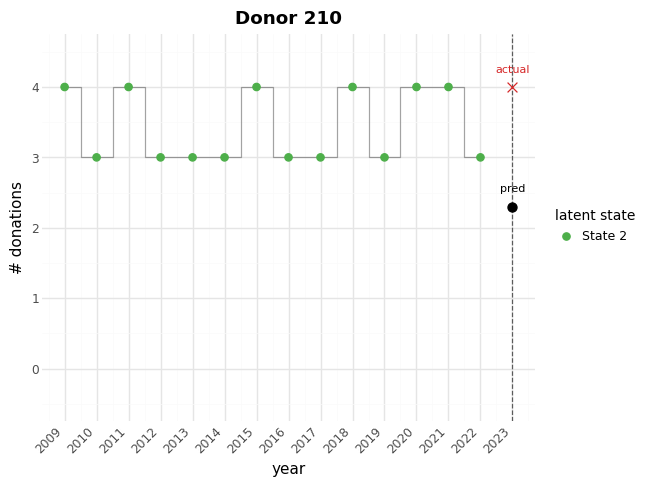

In [62]:
# Plot with plotnine: observed counts + latent states + next-year prediction (robust)
import numpy as np
import pandas as pd
from plotnine import (
    ggplot, aes, geom_point, geom_step, geom_vline, geom_text,
    scale_color_manual, scale_x_continuous, scale_y_continuous,
    labs, theme_minimal, theme, element_text, guides, guide_legend
)

def plot_donor_gg(idx,
                  obs_torch,
                  paths,
                  years,
                  expected_next=None,    # float, predicted expected donations for next year
                  y_true_next=None,      # int, actual donations next year (if available)
                  next_year=None,        # int, defaults to years[-1] + 1
                  state_cols=None,       # list of colors for states
                  title_prefix="Donor",
                  y_max=4):
    """
    Plot observed yearly donations colored by latent state (Viterbi),
    plus markers for predicted and actual next-year donations.

    Parameters
    ----------
    idx : int
        Donor index.
    obs_torch : array-like or torch.Tensor (N, T)
        Observed counts.
    paths : array-like or torch.Tensor (N, T)
        Latent states (e.g., Viterbi), ints in 0..K-1.
    years : array-like (T,)
        Calendar years for the x-axis (must match T).
    expected_next : float or None
        Predicted expected donations for next_year.
    y_true_next : int or None
        Actual number of donations at next_year (if available).
    next_year : int or None
        Year for the prediction point. Defaults to years[-1] + 1.
    state_cols : list[str] or None
        Color palette for states; if None, uses an extended Set1-like palette.
    title_prefix : str
        Plot title prefix.
    y_max : int
        Top of y-axis (default 4 → shows 0..4 and clamps visually).

    Returns
    -------
    plotnine.ggplot
        The assembled ggplot object.
    """
    # --- Extract donor slice as numpy ---
    x = obs_torch[idx].detach().cpu().numpy() if hasattr(obs_torch, "detach") else np.asarray(obs_torch[idx])
    z = paths[idx].detach().cpu().numpy()     if hasattr(paths, "detach")     else np.asarray(paths[idx], dtype=int)
    years = np.asarray(years, dtype=int)

    T = len(x)
    if len(years) != T:
        raise ValueError("Length of 'years' must match the time dimension T for the donor.")

    # --- Build state palette and labels ---
    K = int(np.max(z)) + 1 if z.size > 0 else 1
    if state_cols is None:
        default_cols = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#ffff33',
                        '#a65628', '#f781bf', '#999999']
        state_cols = default_cols[:K]
    state_labels = [f"State {k}" for k in range(K)]
    z_labs = [state_labels[s] for s in z]

    # --- Observed data frame ---
    df_obs = pd.DataFrame({
        "year": years,
        "donations": x,
        "state": z_labs
    })

    # --- Prediction annotations ---
    if next_year is None:
        next_year = int(years[-1] + 1)

    rows_pred = []
    if expected_next is not None:
        rows_pred.append({"year": next_year, "donations": expected_next, "kind": "Predicted"})
    if y_true_next is not None:
        rows_pred.append({"year": next_year, "donations": y_true_next, "kind": "Actual"})
    df_pred = pd.DataFrame(rows_pred) if rows_pred else pd.DataFrame(columns=["year", "donations", "kind"])

    # --- Axis limits and breaks ---
    y_low, y_high = -0.5, float(y_max) + 0.5
    x_breaks = list(np.unique(np.concatenate([years, np.array([next_year])])))

    # --- Base plot ---
    p = (
        ggplot(df_obs, aes("year", "donations"))
        + geom_step(direction="mid", color="black", alpha=0.35)
        + geom_point(aes(color="state"), size=2.5)
        + scale_color_manual(values=state_cols, name="latent state",
                             breaks=state_labels, labels=state_labels)
        + scale_x_continuous(breaks=x_breaks)
        + scale_y_continuous(limits=(y_low, y_high), breaks=list(range(0, int(y_max) + 1)))
        + labs(title=f"{title_prefix} {idx}", x="year", y="# donations")
        + theme_minimal()
        + theme(
            axis_text_x=element_text(rotation=45, ha="right"),
            legend_title=element_text(size=10),
            legend_text=element_text(size=9),
            plot_title=element_text(weight="bold")
        )
        + guides(color=guide_legend(title="latent state"))
    )

    # --- Next-year markers and labels ---
    if not df_pred.empty:
        p = p + geom_vline(xintercept=next_year, linetype="dashed", alpha=0.6)

        if (df_pred["kind"] == "Predicted").any():
            p = p + geom_point(
                mapping=aes("year", "donations"),
                data=df_pred[df_pred["kind"] == "Predicted"],
                color="black",
                size=3.2,
                show_legend=False
            ) + geom_text(
                mapping=aes("year", "donations"),
                data=df_pred[df_pred["kind"] == "Predicted"],
                label="pred",
                nudge_y=0.25,
                size=8,
                color="black",
                show_legend=False
            )

        if (df_pred["kind"] == "Actual").any():
            p = p + geom_point(
                mapping=aes("year", "donations"),
                data=df_pred[df_pred["kind"] == "Actual"],
                color="#d62728",
                size=3.5,
                shape="x",
                show_legend=False
            ) + geom_text(
                mapping=aes("year", "donations"),
                data=df_pred[df_pred["kind"] == "Actual"],
                label="actual",
                nudge_y=0.25,
                size=8,
                color="#d62728",
                show_legend=False
            )
    return p


# --------------------------
# Example usage
# --------------------------
# Suppose:
#   - obs_torch: torch.Tensor (N,T) of counts
#   - paths: array-like (N,T) Viterbi states
#   - df: polars or pandas frame with birth_year and gender_code columns
#   - predict_donor: function defined earlier (GLM emissions compatible)

# Pick a donor and define historical years (exclude the last observed year for holdout)
i = 210
years_hist = np.arange(2009, 2023)  # 2009..2022
year_next  = 2023

# Historical counts for donor i
counts_hist = obs_torch[i, :len(years_hist)].detach().cpu().numpy().tolist()

# Donor metadata (adapt to your data container)
birth_year_indiv = int(df["birth_year"][i])
gender_indiv = "F" if int(df["gender_code"][i]) == 1 else "M"

W_A     = pyro.param("W_A").detach().cpu().numpy()       # (K, K, C_A)
beta_em = pyro.param("beta_em").detach().cpu().numpy()   # (K, 1 + C_em)
C_A  = W_A.shape[2]
C_em = beta_em.shape[1] - 1

# 2) Medie delle covariate di transizione dal training (se disponibili)
try:
    xA_means = cov_tran_torch.mean(dim=(0,1)).detach().cpu().numpy().astype(np.float32)  # (C_A,)
    if xA_means.shape[0] != C_A:
        # Fallback se dimensione non allineata
        tmp = np.zeros(C_A, dtype=np.float32)
        m = min(C_A, xA_means.shape[0])
        tmp[:m] = xA_means[:m]
        xA_means = tmp
except NameError:
    xA_means = np.zeros(C_A, dtype=np.float32)

# 3) Builder per x_A: primi 2 slot = [age_norm, covid], resto = medie (o 0)
def make_xA_builder_with_means(CA, feature_means=None, covid_years=(2020, 2021, 2022)):
    means = feature_means if feature_means is not None else np.zeros(CA, dtype=np.float32)
    def _builder(years, birth_year, gcode):
        years = np.asarray(years, dtype=int)
        T = len(years)
        age_norm = (years - birth_year - ages_mean) / ages_std
        covid = np.isin(years, covid_years).astype(float)
        X = np.tile(means, (T, 1)).astype(np.float32)
        # Assunzione: col 0=age_norm, col 1=covid
        X[:, 0] = age_norm.astype(np.float32)
        X[:, 1] = covid.astype(np.float32)
        return X
    return _builder

x_A_builder = make_xA_builder_with_means(C_A, xA_means)

# 4) Builder per x_em se C_em != 3 (padding con zeri)
def make_xem_builder_pad(Cem, covid_years=(2020, 2021, 2022)):
    def _builder(years, birth_year, gcode):
        years = np.asarray(years, dtype=int)
        T = len(years)
        age_norm = (years - birth_year - ages_mean) / ages_std
        covid = np.isin(years, covid_years).astype(float)
        base = np.stack([np.repeat(gcode, T), age_norm, covid], axis=1).astype(np.float32)
        if Cem > 3:
            extra = np.zeros((T, Cem - 3), dtype=np.float32)
            return np.concatenate([base, extra], axis=1)
        else:
            return base[:, :Cem].astype(np.float32)
    return _builder

x_em_builder = None if C_em == 3 else make_xem_builder_pad(C_em)

# 5) Chiamata a predict_donor con i builder
pred = predict_donor(
    birth_year=birth_year_indiv,
    gender=gender_indiv,
    history_years=years_hist.tolist(),
    history_counts=counts_hist,
    next_year=year_next,
    max_k=4,
    x_A_builder=x_A_builder,
    x_em_builder=x_em_builder
)


# Actual next-year donations (first year outside 'years_hist')
y_true_next = int(obs_torch[i, len(years_hist)].detach().cpu().item())

T_hist = len(years_hist)
N = obs_torch.shape[0]

import numpy as np
paths = np.zeros((N, T_hist), dtype=int)   # placeholder per tutti
paths[i, :] = np.asarray(pred["viterbi_states"], dtype=int)

# Ora puoi plottare
p = plot_donor_gg(
    idx=i,
    obs_torch=obs_torch[:, :T_hist],
    paths=paths,
    years=years_hist,
    expected_next=pred["expected_next"],
    y_true_next=int(obs_torch[i, T_hist].detach().cpu().item()),
    next_year=year_next,
    y_max=4
)
p

# Comparison with a GLM

## Definizione modello GLM Poisson in Pyro

- $y \sim \mathrm{Poisson}(\mu)$
- $\log \mu = \beta_0 + \beta_1 \text{birth\_year\_norm} + \beta_2 \text{gender}$

Stimiamo il **numero totale di donazioni** a persona: per confronto 1:1 con l’HMM (che fa predizione “anno dopo anno”) useremo la previsione sul test come “donazioni attese prossimo anno”.

In [65]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam

# ---------------------------
# Poisson GLM with log link
# ---------------------------
def glm_poisson_model(X, y=None, param_name="glm_beta"):
    # X: (N, C), y: (N,)
    assert X.dim() == 2, "X must be (N, C)"
    N, C = X.shape
    beta = pyro.param(param_name, torch.zeros(C + 1, device=X.device))  # intercept + C slopes
    log_mu = beta[0] + (X @ beta[1:].unsqueeze(-1)).squeeze(-1)         # (N,)
    mu = log_mu.exp()
    with pyro.plate("data", N):
        pyro.sample("obs", dist.Poisson(mu), obs=y)

def glm_poisson_guide(X, y=None, param_name="glm_beta"):
    # Mean-field guide is empty: we use point estimates via pyro.param in the model.
    pass

# ---------------------------
# Train
# ---------------------------
def fit_glm_poisson(X, y, steps=3000, lr=1e-2, param_name="glm_beta", verbose_every=500, save_path="glm_poisson_params.pt"):
    X = X.detach()
    y = y.detach().float()  # Poisson log_prob accetta float
    pyro.clear_param_store()
    svi = SVI(
        lambda X_, y_: glm_poisson_model(X_, y_, param_name),
        lambda X_, y_: glm_poisson_guide(X_, y_, param_name),
        Adam({"lr": lr}),
        loss=Trace_ELBO()
    )
    loss_hist = []
    for s in range(steps):
        loss = svi.step(X, y)
        if verbose_every and s % verbose_every == 0:
            print(f"step {s:4d}: loss={loss:.3f}")
        loss_hist.append(loss)
    # Save only the GLM params (store currently contains only them if you cleared before)
    pyro.get_param_store().save(save_path)
    return loss_hist

# ---------------------------
# Predict and metrics
# ---------------------------
@torch.no_grad()
def glm_poisson_predict(X, param_name="glm_beta", return_proba=True):
    X = X.detach()
    beta = pyro.param(param_name)
    log_mu = beta[0] + (X @ beta[1:].unsqueeze(-1)).squeeze(-1)
    mu = log_mu.exp()  # expected counts
    if return_proba:
        p_donate = 1.0 - torch.exp(-mu)  # P(Y>0 | mu)
        return mu, p_donate
    return mu

@torch.no_grad()
def glm_poisson_evaluate(X, y, param_name="glm_beta"):
    X = X.detach()
    y = y.detach().float()
    mu = glm_poisson_predict(X, param_name, return_proba=False)
    # Metrics
    mae = torch.mean(torch.abs(mu - y)).item()
    rmse = torch.sqrt(torch.mean((mu - y) ** 2)).item()
    # Poisson NLL per observation: -log p(y|mu) = mu - y*log(mu) + log(y!)
    # Use dist.Poisson for stable log_prob
    nll = -torch.mean(dist.Poisson(mu).log_prob(y)).item()
    brier = torch.mean(( (1.0 - torch.exp(-mu)) - (y > 0).float() ) ** 2).item()
    return {"MAE": mae, "RMSE": rmse, "NLL": nll, "Brier(y>0)": brier}

In [80]:
# y_train: last-year counts, X_train: corresponding covariates
y_train = obs_train[:, -1].float()
X_train = cov_train
loss_hist = fit_glm_poisson(X_train, y_train, steps=100, lr=1e-1, verbose_every=10)

step    0: loss=11024.032
step   10: loss=10705.723
step   20: loss=10672.215
step   30: loss=10662.581
step   40: loss=10661.648
step   50: loss=10659.482
step   60: loss=10658.365
step   70: loss=10658.055
step   80: loss=10657.927
step   90: loss=10657.897


## Evaluation

Save and load the model

In [71]:
pyro.get_param_store().load("glm_poisson_params.pt")
metrics_te = glm_poisson_evaluate(X_test, y_test)
mu_te, p_donate_te = glm_poisson_predict(X_test)
metrics_te

{'MAE': 0.8046337366104126,
 'RMSE': 0.9654988646507263,
 'NLL': 1.2608455419540405,
 'Brier(y>0)': 0.23234914243221283}

## Prediction with HMM

In [72]:
EPS = 1e-30

def softmax_row(x):
    x = x - x.max(axis=-1, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=-1, keepdims=True)

def hmm_forward_predict(
    obs_so_far, xpi, xA, A_base, W_pi, W_A, pi_base, beta_em, cov_emission,
    steps_ahead=1
):
    """
    Predicts E[y_{T+steps_ahead}] with covariate-driven transitions and GLM emissions.

    Parameters
    ----------
    obs_so_far : (N, T_obs) array or None
        Observed history (used only for its length; no filtering).
    xpi : (N, C_pi) float
        Initial-state covariates.
    xA : (N, T_total, C_A) float
        Transition covariates for all times (must cover prediction index).
    A_base : (K, K) float, rows simplex
        Base transition matrix.
    W_pi : (K, C_pi) float
        Initial-state slopes.
    W_A : (K, K, C_A) float
        Transition slopes (row-wise).
    pi_base : (K,) float, simplex
        Base initial state.
    beta_em : (K, 1 + C_em) float
        Emission GLM coefficients (intercept + slopes) per state.
    cov_emission : (N, T_total, C_em) float
        Emission covariates at each time.
    steps_ahead : int
        How many steps ahead from T_obs to predict (>=1).

    Returns
    -------
    y_expected : (N,) float
        Predicted expected donations at prediction time.
    state_dist : (N, K) float
        Belief on hidden state at prediction time (after propagation).
    """
    N = xpi.shape[0]
    K = beta_em.shape[0]
    T_obs = 0 if (obs_so_far is None) else int(obs_so_far.shape[1])

    # 1) Initial alpha via softmax(log π_base + xπ Wπ^T)
    logits_pi = np.log(pi_base + EPS)[None, :] + xpi @ W_pi.T            # (N,K)
    alpha = softmax_row(logits_pi)                                       # (N,K)

    # 2) Propagation for steps_ahead
    #    For each t in [T_obs, T_obs+steps_ahead-1] build Aprob(n) = softmax_row(log A_base + W_A ⋅ xA[n,t,:])
    logA0 = np.log(A_base + EPS)                                         # (K,K)
    for t in range(T_obs, T_obs + steps_ahead):
        x_t = xA[:, t, :]                                                # (N,C_A)
        # slope logits: tensordot over C_A → (N,K,K)
        slope = np.tensordot(x_t, W_A, axes=([1], [2]))                  # (N,K,K)
        logits = logA0[None, :, :] + slope                               # (N,K,K)
        Aprob = softmax_row(logits)                                      # (N,K,K) row-softmax over axis=-1
        alpha = np.einsum('nk,nkj->nj', alpha, Aprob)                    # (N,K)

    # 3) Emission at prediction time
    t_pred = T_obs + steps_ahead - 1
    x_em = cov_emission[:, t_pred, :]                                    # (N,C_em)
    # eta = b0 + X_em @ B^T → (N,K)
    b0 = beta_em[:, 0][None, :]                                          # (1,K)
    B  = beta_em[:, 1:]                                                  # (K,C_em)
    eta = b0 + x_em @ B.T                                                # (N,K)
    lam = np.exp(eta)                                                    # (N,K)

    # Expected count under mixture
    y_expected = (alpha * lam).sum(axis=1)                               # (N,)

    return y_expected, alpha

def load_hmm_params(path=None, return_numpy=True):
    """
    Carica dal ParamStore i parametri chiave dell'HMM con GLM emission.
    """
    if path is not None:
        pyro.get_param_store().load(path)
    ps = pyro.get_param_store()
    def to_np(x):
        return x.detach().cpu().numpy() if return_numpy else x
    W_pi    = to_np(pyro.param("W_pi"))
    W_A     = to_np(pyro.param("W_A"))
    pi_base = to_np(pyro.param("pi_base_map"))
    A_base  = to_np(pyro.param("A_base_map"))
    beta_em = to_np(pyro.param("beta_em"))
    return W_pi, W_A, pi_base, A_base, beta_em

In [73]:
# Carica parametri
W_pi, W_A, pi_base, A_base, beta_em = load_hmm_params("hmm_params.pt")

# Converte tensori PyTorch -> NumPy
obs_test_np         = obs_test.detach().cpu().numpy()
xpi_test_np         = xpi_test.detach().cpu().numpy()
xA_test_np          = xA_test.detach().cpu().numpy()
cov_emission_test_np= cov_emission_test.detach().cpu().numpy()

# Predici y_T (one-step ahead) usando osservazioni fino a T-1
y_pred_hmm, state_prob = hmm_forward_predict(
    obs_so_far      = obs_test_np[:, :-1],     # up to T-1
    xpi             = xpi_test_np,
    xA              = xA_test_np,
    A_base          = A_base,
    W_pi            = W_pi,
    W_A             = W_A,
    pi_base         = pi_base,
    beta_em         = beta_em,
    cov_emission    = cov_emission_test_np,    # (N_test, T, C_em)
    steps_ahead     = 1
)

In [74]:
y_test = obs_test_np[:, -1]
print(f"HMM(full): pred mean={y_pred_hmm.mean():.2f}  obs mean={y_test.mean():.2f}")
print(f"MSE: {np.mean((y_pred_hmm - y_test)**2):.4f}")
print(f"Accuracy (round): {100*np.mean(np.round(y_pred_hmm)==y_test):.2f}%")

HMM(full): pred mean=0.57  obs mean=0.96
MSE: 1.1291
Accuracy (round): 39.87%
